In [2]:
pip install mysql-connector-python

Note: you may need to restart the kernel to use updated packages.


In [164]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
import mlflow
import sklearn
import warnings
import joblib
import os

import sys

sys.path.append(r"C:\Users\Sidd\telecom-user-analytics")


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from scipy.spatial.distance import euclidean
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score






warnings.filterwarnings("ignore")

In [4]:
df1 = pd.read_csv("telcom_data.csv")
df2 = pd.read_csv("Field Descriptions.xlsx - Sheet1.csv")
df3 = df1 + df2

In [5]:
print(df1.shape)
print(df2.shape)

print(df1.columns.tolist)
print(df2.columns.tolist)

(150001, 55)
(56, 2)
<bound method IndexOpsMixin.tolist of Index(['Bearer Id', 'Start', 'Start ms', 'End', 'End ms', 'Dur. (ms)', 'IMSI',
       'MSISDN/Number', 'IMEI', 'Last Location Name', 'Avg RTT DL (ms)',
       'Avg RTT UL (ms)', 'Avg Bearer TP DL (kbps)', 'Avg Bearer TP UL (kbps)',
       'TCP DL Retrans. Vol (Bytes)', 'TCP UL Retrans. Vol (Bytes)',
       'DL TP < 50 Kbps (%)', '50 Kbps < DL TP < 250 Kbps (%)',
       '250 Kbps < DL TP < 1 Mbps (%)', 'DL TP > 1 Mbps (%)',
       'UL TP < 10 Kbps (%)', '10 Kbps < UL TP < 50 Kbps (%)',
       '50 Kbps < UL TP < 300 Kbps (%)', 'UL TP > 300 Kbps (%)',
       'HTTP DL (Bytes)', 'HTTP UL (Bytes)', 'Activity Duration DL (ms)',
       'Activity Duration UL (ms)', 'Dur. (ms).1', 'Handset Manufacturer',
       'Handset Type', 'Nb of sec with 125000B < Vol DL',
       'Nb of sec with 1250B < Vol UL < 6250B',
       'Nb of sec with 31250B < Vol DL < 125000B',
       'Nb of sec with 37500B < Vol UL',
       'Nb of sec with 6250B < Vol DL <

In [6]:
print(df1.head())

      Bearer Id          Start  Start ms            End  End ms  Dur. (ms)  \
0  1.311450e+19   4/4/19 12:01     770.0  4/25/19 14:35   662.0  1823652.0   
1  1.311450e+19   4/9/19 13:04     235.0   4/25/19 8:15   606.0  1365104.0   
2  1.311450e+19   4/9/19 17:42       1.0  4/25/19 11:58   652.0  1361762.0   
3  1.311450e+19   4/10/19 0:31     486.0   4/25/19 7:36   171.0  1321509.0   
4  1.311450e+19  4/12/19 20:10     565.0  4/25/19 10:40   954.0  1089009.0   

           IMSI  MSISDN/Number          IMEI Last Location Name  ...  \
0  2.082014e+14   3.366496e+10  3.552121e+13        9.16457E+15  ...   
1  2.082019e+14   3.368185e+10  3.579401e+13            L77566A  ...   
2  2.082003e+14   3.376063e+10  3.528151e+13            D42335A  ...   
3  2.082014e+14   3.375034e+10  3.535661e+13            T21824A  ...   
4  2.082014e+14   3.369980e+10  3.540701e+13            D88865A  ...   

   Youtube DL (Bytes)  Youtube UL (Bytes)  Netflix DL (Bytes)  \
0          15854611.0           2

In [7]:
print(df1.dtypes)

Bearer Id                                   float64
Start                                        object
Start ms                                    float64
End                                          object
End ms                                      float64
Dur. (ms)                                   float64
IMSI                                        float64
MSISDN/Number                               float64
IMEI                                        float64
Last Location Name                           object
Avg RTT DL (ms)                             float64
Avg RTT UL (ms)                             float64
Avg Bearer TP DL (kbps)                     float64
Avg Bearer TP UL (kbps)                     float64
TCP DL Retrans. Vol (Bytes)                 float64
TCP UL Retrans. Vol (Bytes)                 float64
DL TP < 50 Kbps (%)                         float64
50 Kbps < DL TP < 250 Kbps (%)              float64
250 Kbps < DL TP < 1 Mbps (%)               float64
DL TP > 1 Mb

In [8]:
print(df1.shape)

(150001, 55)


In [9]:
print(df1.columns.tolist())

['Bearer Id', 'Start', 'Start ms', 'End', 'End ms', 'Dur. (ms)', 'IMSI', 'MSISDN/Number', 'IMEI', 'Last Location Name', 'Avg RTT DL (ms)', 'Avg RTT UL (ms)', 'Avg Bearer TP DL (kbps)', 'Avg Bearer TP UL (kbps)', 'TCP DL Retrans. Vol (Bytes)', 'TCP UL Retrans. Vol (Bytes)', 'DL TP < 50 Kbps (%)', '50 Kbps < DL TP < 250 Kbps (%)', '250 Kbps < DL TP < 1 Mbps (%)', 'DL TP > 1 Mbps (%)', 'UL TP < 10 Kbps (%)', '10 Kbps < UL TP < 50 Kbps (%)', '50 Kbps < UL TP < 300 Kbps (%)', 'UL TP > 300 Kbps (%)', 'HTTP DL (Bytes)', 'HTTP UL (Bytes)', 'Activity Duration DL (ms)', 'Activity Duration UL (ms)', 'Dur. (ms).1', 'Handset Manufacturer', 'Handset Type', 'Nb of sec with 125000B < Vol DL', 'Nb of sec with 1250B < Vol UL < 6250B', 'Nb of sec with 31250B < Vol DL < 125000B', 'Nb of sec with 37500B < Vol UL', 'Nb of sec with 6250B < Vol DL < 31250B', 'Nb of sec with 6250B < Vol UL < 37500B', 'Nb of sec with Vol DL < 6250B', 'Nb of sec with Vol UL < 1250B', 'Social Media DL (Bytes)', 'Social Media UL (

In [10]:
print(df1.isnull().sum())

Bearer Id                                      991
Start                                            1
Start ms                                         1
End                                              1
End ms                                           1
Dur. (ms)                                        1
IMSI                                           570
MSISDN/Number                                 1066
IMEI                                           572
Last Location Name                            1153
Avg RTT DL (ms)                              27829
Avg RTT UL (ms)                              27812
Avg Bearer TP DL (kbps)                          1
Avg Bearer TP UL (kbps)                          1
TCP DL Retrans. Vol (Bytes)                  88146
TCP UL Retrans. Vol (Bytes)                  96649
DL TP < 50 Kbps (%)                            754
50 Kbps < DL TP < 250 Kbps (%)                 754
250 Kbps < DL TP < 1 Mbps (%)                  754
DL TP > 1 Mbps (%)             

In [11]:
print("Duplicate rows:",df1.duplicated().sum())

Duplicate rows: 0


In [12]:
print(df2.head(20).to_string())

                            Fields                                                            Description
0                        bearer id                                                 xDr session identifier
1                        Dur. (ms)                                      Total Duration of the xDR (in ms)
2                            Start                          Start time of the xDR (first frame timestamp)
3                         Start ms  Milliseconds offset of start time for the xDR (first frame timestamp)
4                              End                             End time of the xDR (last frame timestamp)
5                           End ms      Milliseconds offset of end time of the xDR (last frame timestamp)
6                         Dur. (s)                                       Total Duration of the xDR (in s)
7                             IMSI                               International Mobile Subscriber Identity
8                    MSISDN/Number          MS

In [13]:
df1.isna().sum().sort_values(ascending=False)

Nb of sec with 37500B < Vol UL              130254
Nb of sec with 6250B < Vol UL < 37500B      111843
Nb of sec with 125000B < Vol DL              97538
TCP UL Retrans. Vol (Bytes)                  96649
Nb of sec with 31250B < Vol DL < 125000B     93586
Nb of sec with 1250B < Vol UL < 6250B        92894
Nb of sec with 6250B < Vol DL < 31250B       88317
TCP DL Retrans. Vol (Bytes)                  88146
HTTP UL (Bytes)                              81810
HTTP DL (Bytes)                              81474
Avg RTT DL (ms)                              27829
Avg RTT UL (ms)                              27812
Last Location Name                            1153
MSISDN/Number                                 1066
Bearer Id                                      991
Nb of sec with Vol UL < 1250B                  793
UL TP < 10 Kbps (%)                            792
50 Kbps < UL TP < 300 Kbps (%)                 792
10 Kbps < UL TP < 50 Kbps (%)                  792
UL TP > 300 Kbps (%)           

In [14]:
df1 = df1.drop_duplicates().reset_index(drop=True)

print(f"Shape after removing duplicates: {df1.shape}")

Shape after removing duplicates: (150001, 55)


In [15]:
print(df1[["MSISDN/Number", "IMSI", "IMEI", "Handset Manufacturer", "Handset Type"]].isna().sum())

MSISDN/Number           1066
IMSI                     570
IMEI                     572
Handset Manufacturer     572
Handset Type             572
dtype: int64


In [16]:
numeric_columns = df1.select_dtypes(include="number").columns

print(f"Numeric columns: {len(numeric_columns)}")
print(numeric_columns.tolist())

Numeric columns: 50
['Bearer Id', 'Start ms', 'End ms', 'Dur. (ms)', 'IMSI', 'MSISDN/Number', 'IMEI', 'Avg RTT DL (ms)', 'Avg RTT UL (ms)', 'Avg Bearer TP DL (kbps)', 'Avg Bearer TP UL (kbps)', 'TCP DL Retrans. Vol (Bytes)', 'TCP UL Retrans. Vol (Bytes)', 'DL TP < 50 Kbps (%)', '50 Kbps < DL TP < 250 Kbps (%)', '250 Kbps < DL TP < 1 Mbps (%)', 'DL TP > 1 Mbps (%)', 'UL TP < 10 Kbps (%)', '10 Kbps < UL TP < 50 Kbps (%)', '50 Kbps < UL TP < 300 Kbps (%)', 'UL TP > 300 Kbps (%)', 'HTTP DL (Bytes)', 'HTTP UL (Bytes)', 'Activity Duration DL (ms)', 'Activity Duration UL (ms)', 'Dur. (ms).1', 'Nb of sec with 125000B < Vol DL', 'Nb of sec with 1250B < Vol UL < 6250B', 'Nb of sec with 31250B < Vol DL < 125000B', 'Nb of sec with 37500B < Vol UL', 'Nb of sec with 6250B < Vol DL < 31250B', 'Nb of sec with 6250B < Vol UL < 37500B', 'Nb of sec with Vol DL < 6250B', 'Nb of sec with Vol UL < 1250B', 'Social Media DL (Bytes)', 'Social Media UL (Bytes)', 'Google DL (Bytes)', 'Google UL (Bytes)', 'Email 

In [17]:
categorical_columns = df1.select_dtypes(include="object").columns

print(f"Categorical columns: {len(categorical_columns)}")
print(categorical_columns.tolist())

Categorical columns: 5
['Start', 'End', 'Last Location Name', 'Handset Manufacturer', 'Handset Type']


In [18]:
identifier_columns = [
    "Bearer Id",
    "IMSI",
    "MSISDN/Number",
    "IMEI"
]

session_columns = [
    "Start",
    "Start ms",
    "End",
    "End ms",
    "Dur. (ms)",
    "Dur. (ms).1"
]

device_columns = [
    "Last Location Name",
    "Handset Manufacturer",
    "Handset Type"
]

categorical_columns = [
    "Start",
    "End",
    "Last Location Name",
    "Handset Manufacturer",
    "Handset Type"
]

experience_columns = [
    "Avg RTT DL (ms)",
    "Avg RTT UL (ms)",
    "Avg Bearer TP DL (kbps)",
    "Avg Bearer TP UL (kbps)",
    "TCP DL Retrans. Vol (Bytes)",
    "TCP UL Retrans. Vol (Bytes)"
]

application_columns = [
    "Social Media DL (Bytes)",
    "Social Media UL (Bytes)",
    "Google DL (Bytes)",
    "Google UL (Bytes)",
    "Email DL (Bytes)",
    "Email UL (Bytes)",
    "Youtube DL (Bytes)",
    "Youtube UL (Bytes)",
    "Netflix DL (Bytes)",
    "Netflix UL (Bytes)",
    "Gaming DL (Bytes)",
    "Gaming UL (Bytes)",
    "Other DL (Bytes)",
    "Other UL (Bytes)"
]

traffic_columns = [
    "Total DL (Bytes)",
    "Total UL (Bytes)"
]


In [19]:
df1 = df1.dropna(subset=["MSISDN/Number"]).reset_index(drop=True)

print(f"Shape: {df1.shape}")
print(f"Missing MSISDN: {df1['MSISDN/Number'].isna().sum()}")

Shape: (148935, 55)
Missing MSISDN: 0


In [20]:
df2.head(10)
print(df2.to_string(index=False))
df2

                                  Fields                                                                         Description
                               bearer id                                                              xDr session identifier
                               Dur. (ms)                                                   Total Duration of the xDR (in ms)
                                   Start                                       Start time of the xDR (first frame timestamp)
                                Start ms               Milliseconds offset of start time for the xDR (first frame timestamp)
                                     End                                          End time of the xDR (last frame timestamp)
                                  End ms                   Milliseconds offset of end time of the xDR (last frame timestamp)
                                Dur. (s)                                                    Total Duration of the xDR (in s)


,Fields,Description
0,bearer id,xDr session identifier
1,Dur. (ms),Total Duration of the xDR (in ms)
2,Start,Start time of the xDR (first frame timestamp)
3,Start ms,Milliseconds offset of start time for the xDR ...
4,End,End time of the xDR (last frame timestamp)
5,End ms,Milliseconds offset of end time of the xDR (la...
6,Dur. (s),Total Duration of the xDR (in s)
7,IMSI,International Mobile Subscriber Identity
8,MSISDN/Number,MS International PSTN/ISDN Number of mobile - ...
9,IMEI,International Mobile Equipment Identity


In [21]:
print("Unique customers:", df1["MSISDN/Number"].nunique())
print("Unique IMSIs:", df1["IMSI"].nunique())
print("Unique IMEIs:", df1["IMEI"].nunique())
print("Unique handsets:", df1["Handset Type"].nunique())
print("Unique manufacturers:", df1["Handset Manufacturer"].nunique())

Unique customers: 106856
Unique IMSIs: 106855
Unique IMEIs: 106862
Unique handsets: 1394
Unique manufacturers: 170


In [22]:
print(df1["MSISDN/Number"].value_counts().describe())

count    106856.000000
mean          1.393792
std           0.806022
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          18.000000
Name: count, dtype: float64


In [23]:
df_clean = df1.drop_duplicates().reset_index(drop=True)

print("shape:",df_clean.shape)
print("Duplicates:", df_clean.duplicated().sum())

shape: (148935, 55)
Duplicates: 0


In [24]:
df_clean = df_clean.dropna(subset=["MSISDN/Number"]).reset_index(drop=True)

print("Shape:", df_clean.shape)
print("Missing MSISDN:", df_clean["MSISDN/Number"].isna().sum())

Shape: (148935, 55)
Missing MSISDN: 0


In [25]:
missing = df_clean.isna().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

Nb of sec with 37500B < Vol UL              129329
Nb of sec with 6250B < Vol UL < 37500B      111106
Nb of sec with 125000B < Vol DL              96984
TCP UL Retrans. Vol (Bytes)                  96192
Nb of sec with 31250B < Vol DL < 125000B     93106
Nb of sec with 1250B < Vol UL < 6250B        92426
Nb of sec with 6250B < Vol DL < 31250B       87911
TCP DL Retrans. Vol (Bytes)                  87796
HTTP UL (Bytes)                              81508
HTTP DL (Bytes)                              81171
Avg RTT DL (ms)                              27644
Avg RTT UL (ms)                              27625
Nb of sec with Vol UL < 1250B                  768
10 Kbps < UL TP < 50 Kbps (%)                  767
UL TP < 10 Kbps (%)                            767
UL TP > 300 Kbps (%)                           767
50 Kbps < UL TP < 300 Kbps (%)                 767
Nb of sec with Vol DL < 6250B                  721
50 Kbps < DL TP < 250 Kbps (%)                 720
DL TP < 50 Kbps (%)            

In [26]:
missing_pct = (df_clean.isna().sum() / len(df_clean) * 100)

missing_pct = (
    missing_pct[missing_pct > 0]
    .sort_values(ascending=False)
)

print(missing_pct)

Nb of sec with 37500B < Vol UL              86.835868
Nb of sec with 6250B < Vol UL < 37500B      74.600329
Nb of sec with 125000B < Vol DL             65.118340
TCP UL Retrans. Vol (Bytes)                 64.586565
Nb of sec with 31250B < Vol DL < 125000B    62.514520
Nb of sec with 1250B < Vol UL < 6250B       62.057945
Nb of sec with 6250B < Vol DL < 31250B      59.026421
TCP DL Retrans. Vol (Bytes)                 58.949206
HTTP UL (Bytes)                             54.727230
HTTP DL (Bytes)                             54.500957
Avg RTT DL (ms)                             18.561117
Avg RTT UL (ms)                             18.548360
Nb of sec with Vol UL < 1250B                0.515661
10 Kbps < UL TP < 50 Kbps (%)                0.514990
UL TP < 10 Kbps (%)                          0.514990
UL TP > 300 Kbps (%)                         0.514990
50 Kbps < UL TP < 300 Kbps (%)               0.514990
Nb of sec with Vol DL < 6250B                0.484104
50 Kbps < DL TP < 250 Kbps (

In [27]:
high_missing_cols = missing_pct[missing_pct > 50].index

df_clean[high_missing_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Nb of sec with 37500B < Vol UL,19606.0,1.501127e+02,1.223408e+03,1.0,2.00,8.0,35.0,5.055300e+04
Nb of sec with 6250B < Vol UL < 37500B,37829.0,1.422624e+02,9.975548e+02,1.0,3.00,8.0,32.0,4.956500e+04
Nb of sec with 125000B < Vol DL,51951.0,9.944611e+02,2.547965e+03,1.0,20.00,130.0,703.0,8.147600e+04
TCP UL Retrans. Vol (Bytes),52743.0,7.662475e+05,2.660460e+07,1.0,4721.50,21121.0,84695.5,2.908226e+09
Nb of sec with 31250B < Vol DL < 125000B,55829.0,8.159600e+02,1.848328e+03,1.0,26.00,166.0,766.0,5.852500e+04
Nb of sec with 1250B < Vol UL < 6250B,56509.0,3.427321e+02,1.452053e+03,1.0,10.00,53.0,205.0,8.541200e+04
Nb of sec with 6250B < Vol DL < 31250B,61024.0,9.712849e+02,1.954300e+03,1.0,39.00,290.0,1100.0,6.691300e+04
TCP DL Retrans. Vol (Bytes),61139.0,2.088418e+07,1.825943e+08,2.0,36098.50,576130.0,3790785.0,4.294426e+09
HTTP UL (Bytes),67427.0,3.269792e+06,1.967729e+07,40.0,24617.00,232801.0,1563497.0,1.491890e+09
HTTP DL (Bytes),67764.0,1.155124e+08,9.684604e+08,40.0,113737.75,1976879.0,25698389.5,7.253064e+10


In [28]:
df_clean = df_clean.copy()

In [29]:
id_cols = [
    "Bearer Id",
    "IMSI",
    "MSISDN/Number",
    "IMEI"
]

numeric_cols = df_clean.select_dtypes(include="number").columns

numeric_impute_cols = [
    col for col in numeric_cols
    if col not in id_cols and df_clean[col].isna().any()
]

for col in numeric_impute_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mean())

In [30]:
df_clean["Last Location Name"] = (
    df_clean["Last Location Name"]
    .fillna(df_clean["Last Location Name"].mode()[0])
)

In [31]:
df_clean = df_clean.dropna(subset=["Bearer Id"]).reset_index(drop=True)

In [32]:
remaining_missing = df_clean.isna().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

print(remaining_missing)

Series([], dtype: int64)


In [33]:
print("Final shape:", df_clean.shape)

Final shape: (148506, 55)


In [34]:
id_cols = [
    "Bearer Id",
    "IMSI",
    "MSISDN/Number",
    "IMEI"
]

numeric_analysis_cols = [
    col for col in df_clean.select_dtypes(include="number").columns
    if col not in id_cols
]

print("Number of analysis columns:", len(numeric_analysis_cols))
print(numeric_analysis_cols)

Number of analysis columns: 46
['Start ms', 'End ms', 'Dur. (ms)', 'Avg RTT DL (ms)', 'Avg RTT UL (ms)', 'Avg Bearer TP DL (kbps)', 'Avg Bearer TP UL (kbps)', 'TCP DL Retrans. Vol (Bytes)', 'TCP UL Retrans. Vol (Bytes)', 'DL TP < 50 Kbps (%)', '50 Kbps < DL TP < 250 Kbps (%)', '250 Kbps < DL TP < 1 Mbps (%)', 'DL TP > 1 Mbps (%)', 'UL TP < 10 Kbps (%)', '10 Kbps < UL TP < 50 Kbps (%)', '50 Kbps < UL TP < 300 Kbps (%)', 'UL TP > 300 Kbps (%)', 'HTTP DL (Bytes)', 'HTTP UL (Bytes)', 'Activity Duration DL (ms)', 'Activity Duration UL (ms)', 'Dur. (ms).1', 'Nb of sec with 125000B < Vol DL', 'Nb of sec with 1250B < Vol UL < 6250B', 'Nb of sec with 31250B < Vol DL < 125000B', 'Nb of sec with 37500B < Vol UL', 'Nb of sec with 6250B < Vol DL < 31250B', 'Nb of sec with 6250B < Vol UL < 37500B', 'Nb of sec with Vol DL < 6250B', 'Nb of sec with Vol UL < 1250B', 'Social Media DL (Bytes)', 'Social Media UL (Bytes)', 'Google DL (Bytes)', 'Google UL (Bytes)', 'Email DL (Bytes)', 'Email UL (Bytes)', 'Y

In [35]:
missing = df1[numeric_analysis_cols].isna().sum()

missing_summary = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": (missing / len(df1)) * 100
}).sort_values("Missing %", ascending=False)

missing_summary

,Missing Count,Missing %
Nb of sec with 37500B < Vol UL,129329,86.835868
Nb of sec with 6250B < Vol UL < 37500B,111106,74.600329
Nb of sec with 125000B < Vol DL,96984,65.118340
TCP UL Retrans. Vol (Bytes),96192,64.586565
Nb of sec with 31250B < Vol DL < 125000B,93106,62.514520
Nb of sec with 1250B < Vol UL < 6250B,92426,62.057945
Nb of sec with 6250B < Vol DL < 31250B,87911,59.026421
TCP DL Retrans. Vol (Bytes),87796,58.949206
HTTP UL (Bytes),81508,54.727230
HTTP DL (Bytes),81171,54.500957


In [36]:
missing_summary[missing_summary["Missing Count"] > 0]

,Missing Count,Missing %
Nb of sec with 37500B < Vol UL,129329,86.835868
Nb of sec with 6250B < Vol UL < 37500B,111106,74.600329
Nb of sec with 125000B < Vol DL,96984,65.118340
TCP UL Retrans. Vol (Bytes),96192,64.586565
Nb of sec with 31250B < Vol DL < 125000B,93106,62.514520
Nb of sec with 1250B < Vol UL < 6250B,92426,62.057945
Nb of sec with 6250B < Vol DL < 31250B,87911,59.026421
TCP DL Retrans. Vol (Bytes),87796,58.949206
HTTP UL (Bytes),81508,54.727230
HTTP DL (Bytes),81171,54.500957


In [37]:

missing_summary["Category"] = pd.cut(
    missing_summary["Missing %"],
    bins=[-1, 1, 20, 50, 100],
    labels=[
        "Very Low (<1%)",
        "Low (1-20%)",
        "Moderate (20-50%)",
        "High (>50%)"
    ]
)

missing_summary

,Missing Count,Missing %,Category
Nb of sec with 37500B < Vol UL,129329,86.835868,High (>50%)
Nb of sec with 6250B < Vol UL < 37500B,111106,74.600329,High (>50%)
Nb of sec with 125000B < Vol DL,96984,65.118340,High (>50%)
TCP UL Retrans. Vol (Bytes),96192,64.586565,High (>50%)
Nb of sec with 31250B < Vol DL < 125000B,93106,62.514520,High (>50%)
Nb of sec with 1250B < Vol UL < 6250B,92426,62.057945,High (>50%)
Nb of sec with 6250B < Vol DL < 31250B,87911,59.026421,High (>50%)
TCP DL Retrans. Vol (Bytes),87796,58.949206,High (>50%)
HTTP UL (Bytes),81508,54.727230,High (>50%)
HTTP DL (Bytes),81171,54.500957,High (>50%)


In [38]:
missing_summary["Category"].value_counts()

Category
Very Low (<1%)       34
High (>50%)          10
Low (1-20%)           2
Moderate (20-50%)     0
Name: count, dtype: int64

In [39]:
high_missing_cols = missing_summary[
    missing_summary["Missing %"] > 50
].index.tolist()

df1[high_missing_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Nb of sec with 37500B < Vol UL,19606.0,1.501127e+02,1.223408e+03,1.0,2.00,8.0,35.0,5.055300e+04
Nb of sec with 6250B < Vol UL < 37500B,37829.0,1.422624e+02,9.975548e+02,1.0,3.00,8.0,32.0,4.956500e+04
Nb of sec with 125000B < Vol DL,51951.0,9.944611e+02,2.547965e+03,1.0,20.00,130.0,703.0,8.147600e+04
TCP UL Retrans. Vol (Bytes),52743.0,7.662475e+05,2.660460e+07,1.0,4721.50,21121.0,84695.5,2.908226e+09
Nb of sec with 31250B < Vol DL < 125000B,55829.0,8.159600e+02,1.848328e+03,1.0,26.00,166.0,766.0,5.852500e+04
Nb of sec with 1250B < Vol UL < 6250B,56509.0,3.427321e+02,1.452053e+03,1.0,10.00,53.0,205.0,8.541200e+04
Nb of sec with 6250B < Vol DL < 31250B,61024.0,9.712849e+02,1.954300e+03,1.0,39.00,290.0,1100.0,6.691300e+04
TCP DL Retrans. Vol (Bytes),61139.0,2.088418e+07,1.825943e+08,2.0,36098.50,576130.0,3790785.0,4.294426e+09
HTTP UL (Bytes),67427.0,3.269792e+06,1.967729e+07,40.0,24617.00,232801.0,1563497.0,1.491890e+09
HTTP DL (Bytes),67764.0,1.155124e+08,9.684604e+08,40.0,113737.75,1976879.0,25698389.5,7.253064e+10


In [40]:

check_cols = [
    'HTTP DL (Bytes)',
    'HTTP UL (Bytes)',
    'TCP DL Retrans. Vol (Bytes)',
    'TCP UL Retrans. Vol (Bytes)',
    'Nb of sec with 125000B < Vol DL',
    'Nb of sec with 37500B < Vol UL'
]

df1[check_cols].isna().sum()


df1.loc[
    df1['HTTP DL (Bytes)'].isna(),
    ['HTTP DL (Bytes)', 'HTTP UL (Bytes)',
     'Total DL (Bytes)', 'Total UL (Bytes)']
].head(20)

df1.loc[
    df1['TCP DL Retrans. Vol (Bytes)'].isna(),
    ['TCP DL Retrans. Vol (Bytes)',
     'TCP UL Retrans. Vol (Bytes)',
     'Total DL (Bytes)', 'Total UL (Bytes)']
].head(20)

,TCP DL Retrans. Vol (Bytes),TCP UL Retrans. Vol (Bytes),Total DL (Bytes),Total UL (Bytes)
0,NaN,NaN,308879636.0,36749741.0
1,NaN,NaN,653384965.0,53800391.0
2,NaN,NaN,279807335.0,27883638.0
3,NaN,NaN,846028530.0,43324218.0
4,NaN,NaN,569138589.0,38542814.0
5,NaN,NaN,754452212.0,30307754.0
6,NaN,NaN,70562047.0,47925246.0
8,NaN,NaN,861612261.0,42363146.0
10,NaN,NaN,594967693.0,56559490.0
12,NaN,NaN,809144948.0,39654040.0


In [41]:
eda_stats = df1[numeric_analysis_cols].describe().T

eda_stats["skewness"] = df1[numeric_analysis_cols].skew()
eda_stats["kurtosis"] = df1[numeric_analysis_cols].kurtosis()

eda_stats[[
    "count",
    "mean",
    "50%",
    "std",
    "min",
    "max",
    "skewness",
    "kurtosis"
]].sort_values("skewness", ascending=False)

,count,mean,50%,std,min,max,skewness,kurtosis
TCP UL Retrans. Vol (Bytes),52743.0,7.662475e+05,21121.0,2.660460e+07,1.0,2.908226e+09,83.638099,7704.575360
Avg RTT DL (ms),121291.0,1.082247e+02,45.0,5.943000e+02,0.0,9.692300e+04,64.491396,7888.674168
HTTP DL (Bytes),67764.0,1.155124e+08,1976879.0,9.684604e+08,40.0,7.253064e+10,38.740864,2060.585286
UL TP > 300 Kbps (%),148168.0,7.914664e-02,0.0,1.298999e+00,0.0,9.600000e+01,36.111207,1747.166465
HTTP UL (Bytes),67427.0,3.269792e+06,232801.0,1.967729e+07,40.0,1.491890e+09,32.307532,1564.098753
Avg RTT UL (ms),121310.0,1.763724e+01,5.0,8.479305e+01,0.0,7.120000e+03,28.559090,1337.315319
Nb of sec with 1250B < Vol UL < 6250B,56509.0,3.427321e+02,53.0,1.452053e+03,1.0,8.541200e+04,21.955041,842.995915
50 Kbps < UL TP < 300 Kbps (%),148168.0,1.479807e-01,0.0,1.627424e+00,0.0,1.000000e+02,21.885877,669.096874
Nb of sec with 37500B < Vol UL,19606.0,1.501127e+02,8.0,1.223408e+03,1.0,5.055300e+04,21.485054,606.208109
Nb of sec with 6250B < Vol UL < 37500B,37829.0,1.422624e+02,8.0,9.975548e+02,1.0,4.956500e+04,19.561177,555.724124


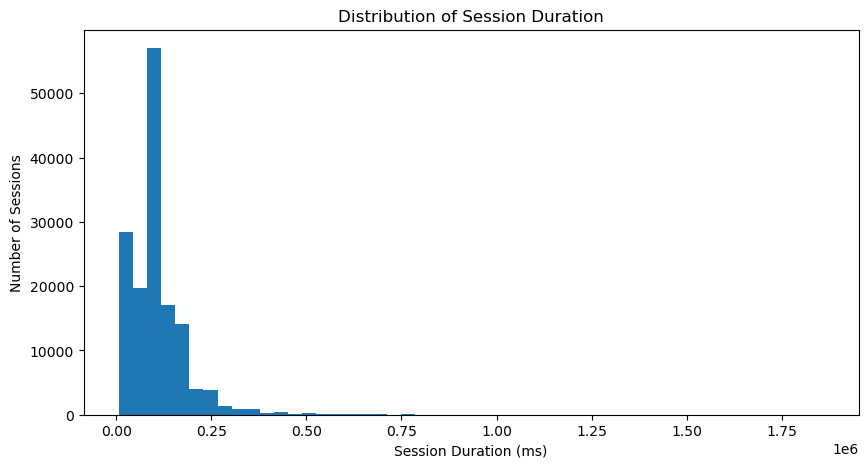

In [42]:
plt.figure(figsize=(10, 5))
plt.hist(df1["Dur. (ms)"].dropna(), bins=50)
plt.xlabel("Session Duration (ms)")
plt.ylabel("Number of Sessions")
plt.title("Distribution of Session Duration")
plt.show()

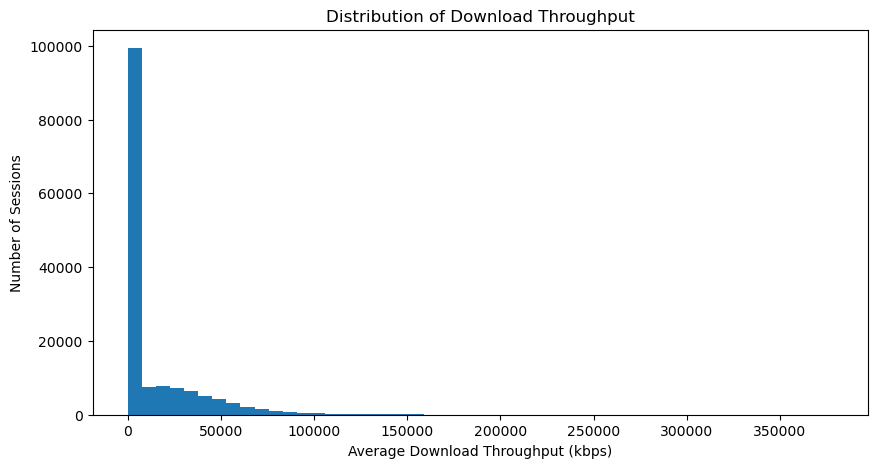

In [43]:
plt.figure(figsize=(10, 5))
plt.hist(df1["Avg Bearer TP DL (kbps)"].dropna(), bins=50)
plt.xlabel("Average Download Throughput (kbps)")
plt.ylabel("Number of Sessions")
plt.title("Distribution of Download Throughput")
plt.show()

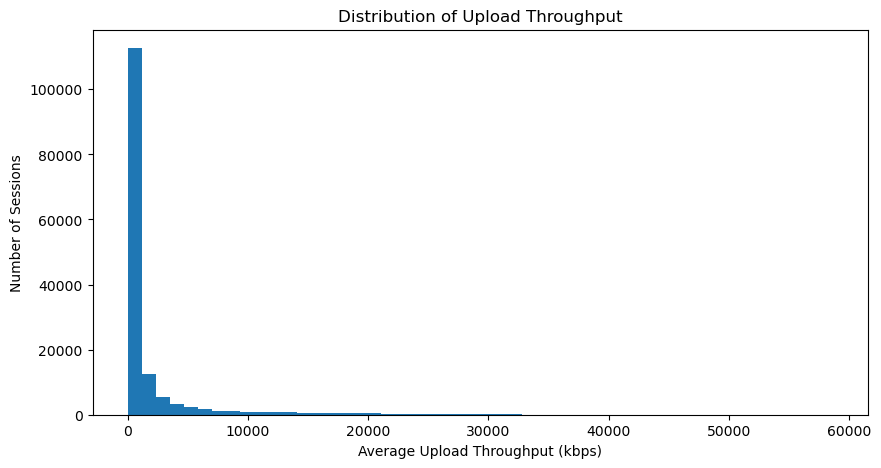

In [44]:
plt.figure(figsize=(10, 5))
plt.hist(df1["Avg Bearer TP UL (kbps)"].dropna(), bins=50)
plt.xlabel("Average Upload Throughput (kbps)")
plt.ylabel("Number of Sessions")
plt.title("Distribution of Upload Throughput")
plt.show()

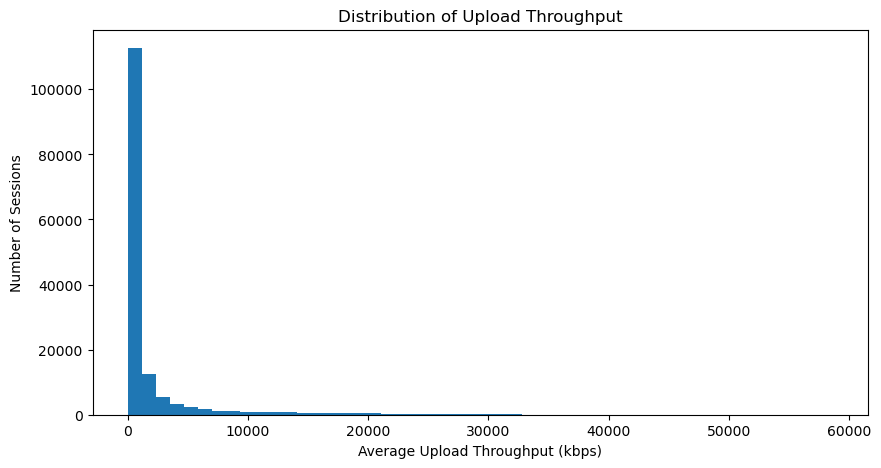

In [45]:
plt.figure(figsize=(10, 5))
plt.hist(df1["Avg Bearer TP UL (kbps)"].dropna(), bins=50)
plt.xlabel("Average Upload Throughput (kbps)")
plt.ylabel("Number of Sessions")
plt.title("Distribution of Upload Throughput")
plt.show()

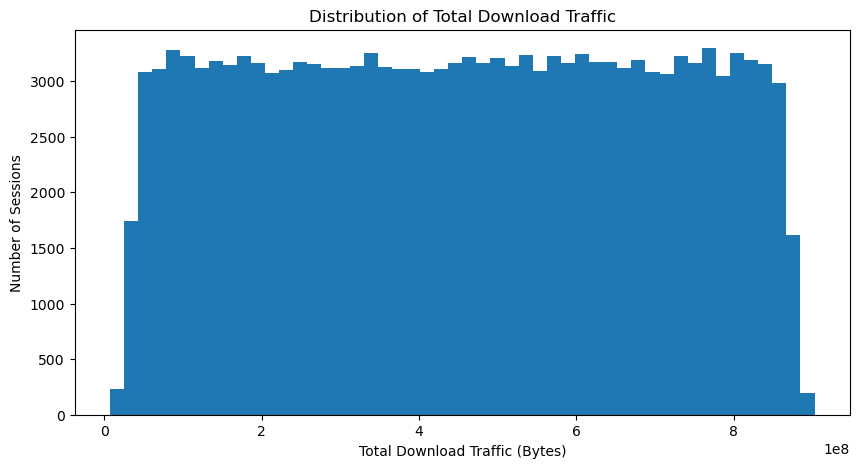

In [46]:
plt.figure(figsize=(10, 5))
plt.hist(df1["Total DL (Bytes)"].dropna(), bins=50)
plt.xlabel("Total Download Traffic (Bytes)")
plt.ylabel("Number of Sessions")
plt.title("Distribution of Total Download Traffic")
plt.show()

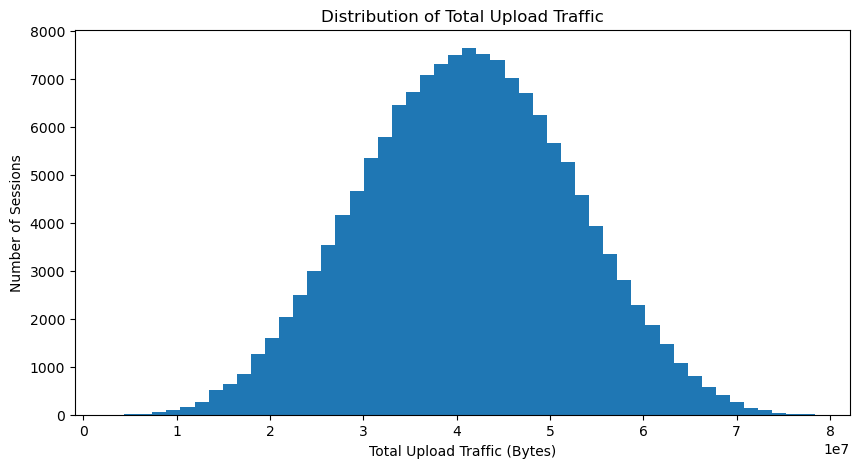

In [47]:
plt.figure(figsize=(10, 5))
plt.hist(df1["Total UL (Bytes)"].dropna(), bins=50)
plt.xlabel("Total Upload Traffic (Bytes)")
plt.ylabel("Number of Sessions")
plt.title("Distribution of Total Upload Traffic")
plt.show()

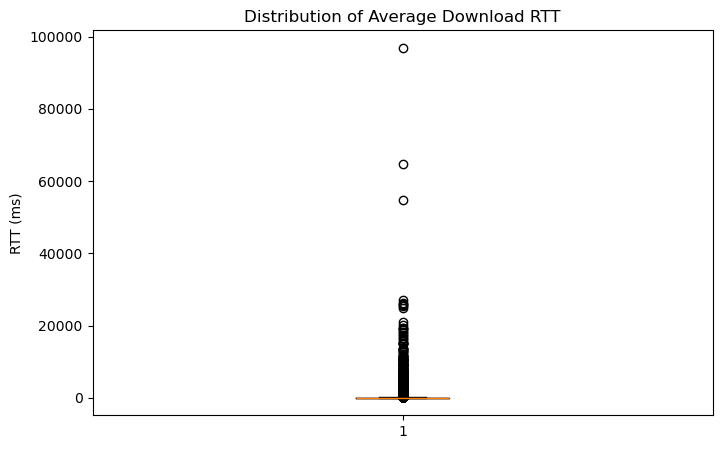

In [48]:
plt.figure(figsize=(8, 5))
plt.boxplot(df1["Avg RTT DL (ms)"].dropna())
plt.ylabel("RTT (ms)")
plt.title("Distribution of Average Download RTT")
plt.show()

In [49]:
outlier_stats = []

for col in numeric_analysis_cols:
    data = df1[col].dropna()

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((data < lower) | (data > upper)).sum()

    outlier_stats.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": outliers,
        "Outlier %": (outliers / len(data)) * 100
    })

outlier_df = pd.DataFrame(outlier_stats)

outlier_df.sort_values(
    "Outlier %",
    ascending=False
).head(15)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
12,DL TP > 1 Mbps (%),0.00,0.00,0.00,0.000000e+00,0.000000e+00,36744,24.791013
14,10 Kbps < UL TP < 50 Kbps (%),0.00,0.00,0.00,0.000000e+00,0.000000e+00,31691,21.388559
11,250 Kbps < DL TP < 1 Mbps (%),0.00,1.00,1.00,-1.500000e+00,2.500000e+00,29472,19.884627
17,HTTP DL (Bytes),113737.75,25698389.50,25584651.75,-3.826324e+07,6.407537e+07,12193,17.993330
19,Activity Duration DL (ms),14885.00,677940.00,663055.00,-9.796975e+05,1.672522e+06,26540,17.819854
20,Activity Duration UL (ms),21548.00,596186.00,574638.00,-8.404090e+05,1.458143e+06,25918,17.402222
29,Nb of sec with Vol UL < 1250B,106.00,2441.00,2335.00,-3.396500e+03,5.943500e+03,25098,16.938995
28,Nb of sec with Vol DL < 6250B,87.00,2650.75,2563.75,-3.758625e+03,6.496375e+03,24441,16.490345
18,HTTP UL (Bytes),24617.00,1563497.00,1538880.00,-2.283703e+06,3.871817e+06,10295,15.268364
13,UL TP < 10 Kbps (%),99.00,100.00,1.00,9.750000e+01,1.015000e+02,21931,14.801442


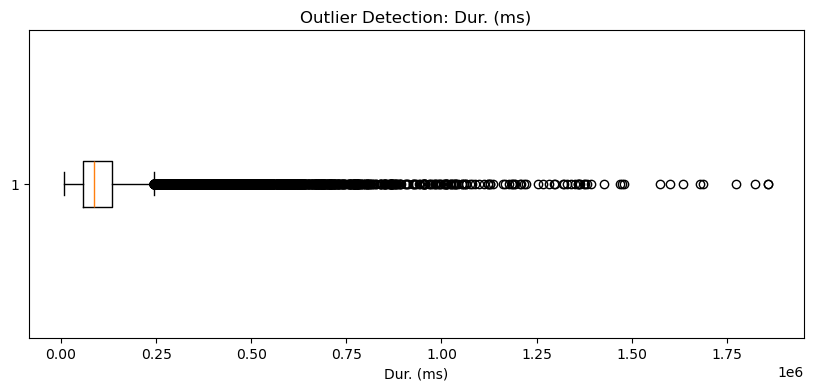

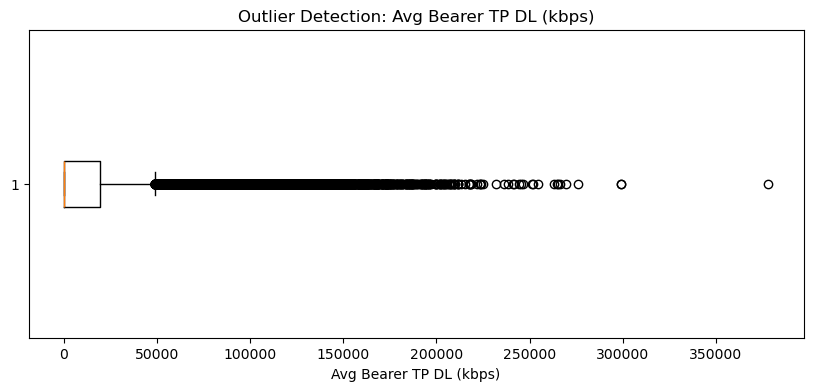

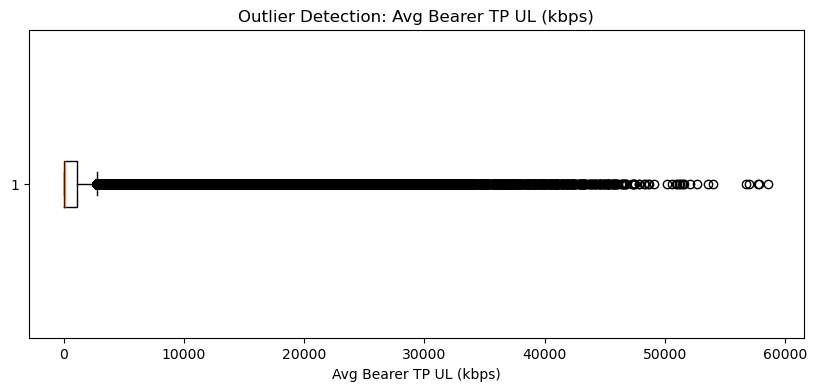

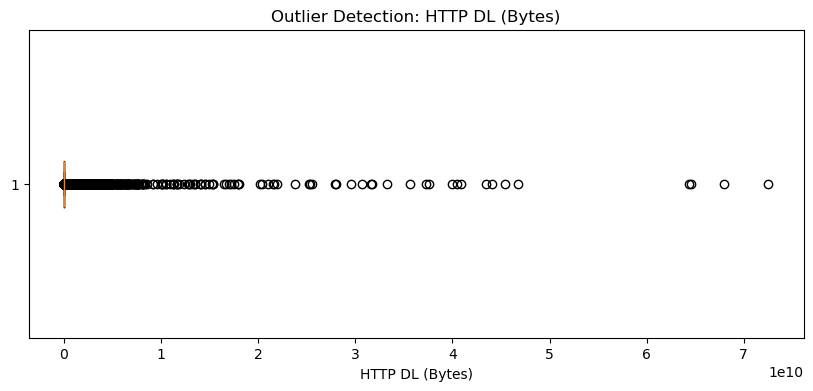

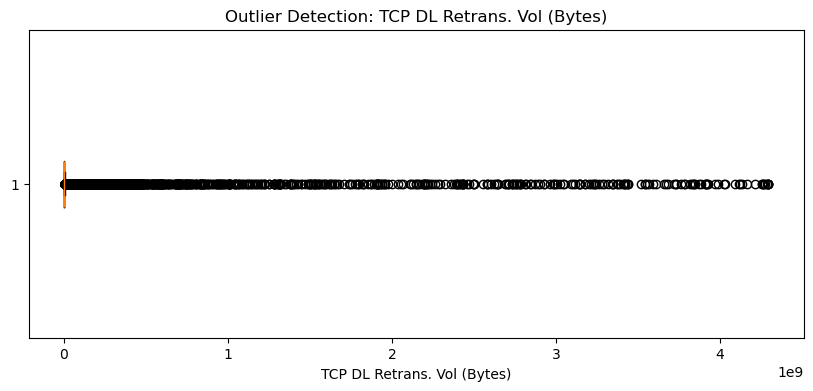

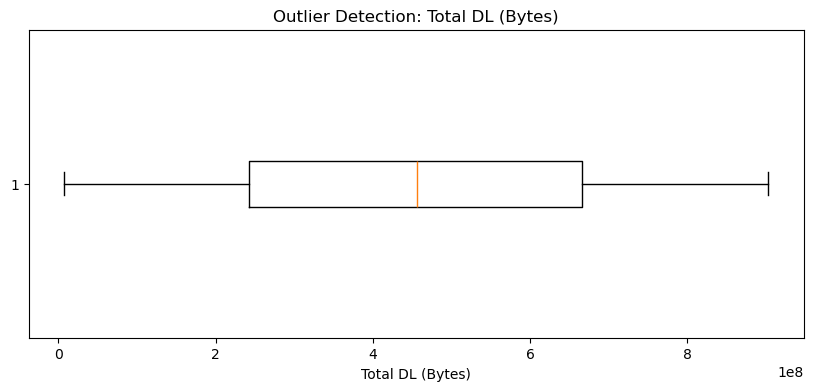

In [50]:
important_outlier_cols = [
    "Dur. (ms)",
    "Avg Bearer TP DL (kbps)",
    "Avg Bearer TP UL (kbps)",
    "HTTP DL (Bytes)",
    "TCP DL Retrans. Vol (Bytes)",
    "Total DL (Bytes)"
]

for col in important_outlier_cols:
    plt.figure(figsize=(10, 4))
    plt.boxplot(df1[col].dropna(), vert=False)
    plt.xlabel(col)
    plt.title(f"Outlier Detection: {col}")
    plt.show()

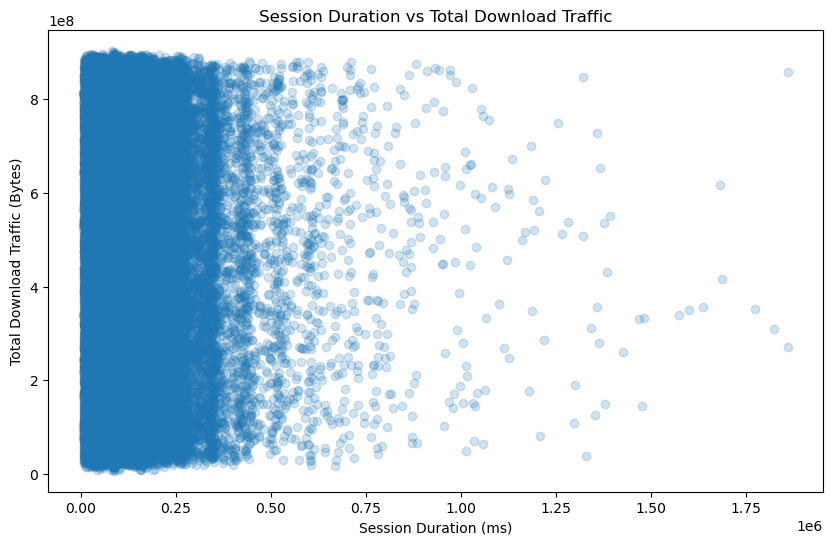

In [51]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df1["Dur. (ms)"],
    df1["Total DL (Bytes)"],
    alpha=0.2
)

plt.xlabel("Session Duration (ms)")
plt.ylabel("Total Download Traffic (Bytes)")
plt.title("Session Duration vs Total Download Traffic")

plt.show()

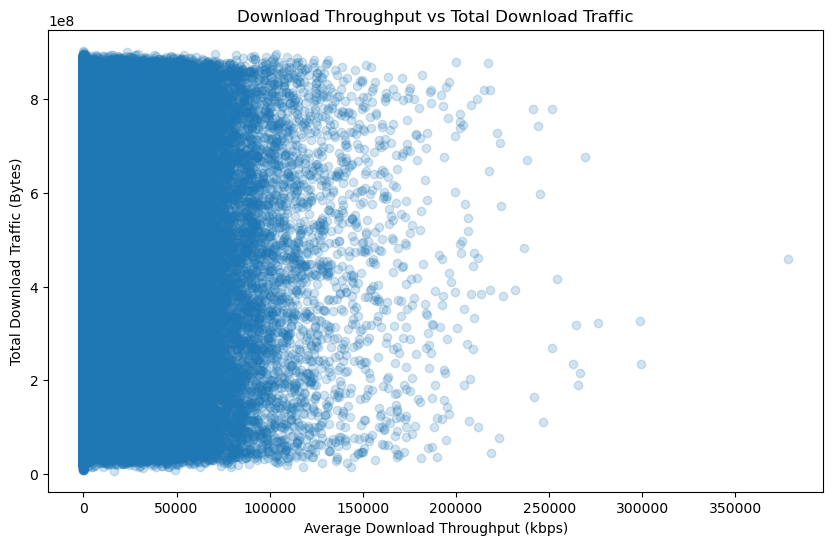

In [52]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df1["Avg Bearer TP DL (kbps)"],
    df1["Total DL (Bytes)"],
    alpha=0.2
)

plt.xlabel("Average Download Throughput (kbps)")
plt.ylabel("Total Download Traffic (Bytes)")
plt.title("Download Throughput vs Total Download Traffic")

plt.show()

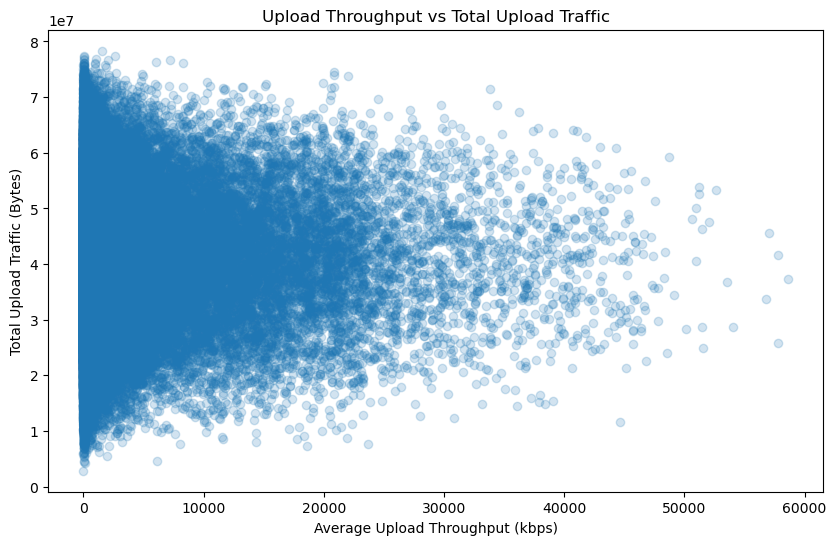

In [53]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df1["Avg Bearer TP UL (kbps)"],
    df1["Total UL (Bytes)"],
    alpha=0.2
)

plt.xlabel("Average Upload Throughput (kbps)")
plt.ylabel("Total Upload Traffic (Bytes)")
plt.title("Upload Throughput vs Total Upload Traffic")

plt.show()

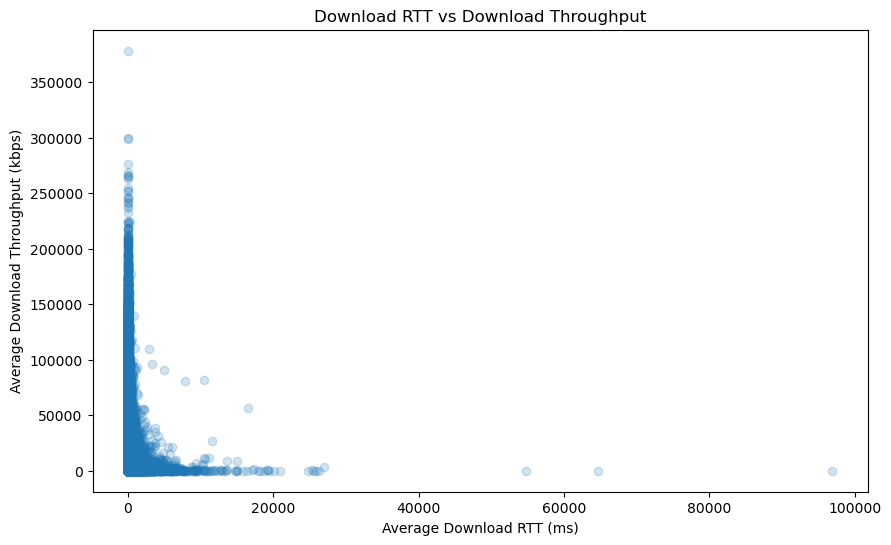

In [54]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df1["Avg RTT DL (ms)"],
    df1["Avg Bearer TP DL (kbps)"],
    alpha=0.2
)

plt.xlabel("Average Download RTT (ms)")
plt.ylabel("Average Download Throughput (kbps)")
plt.title("Download RTT vs Download Throughput")

plt.show()

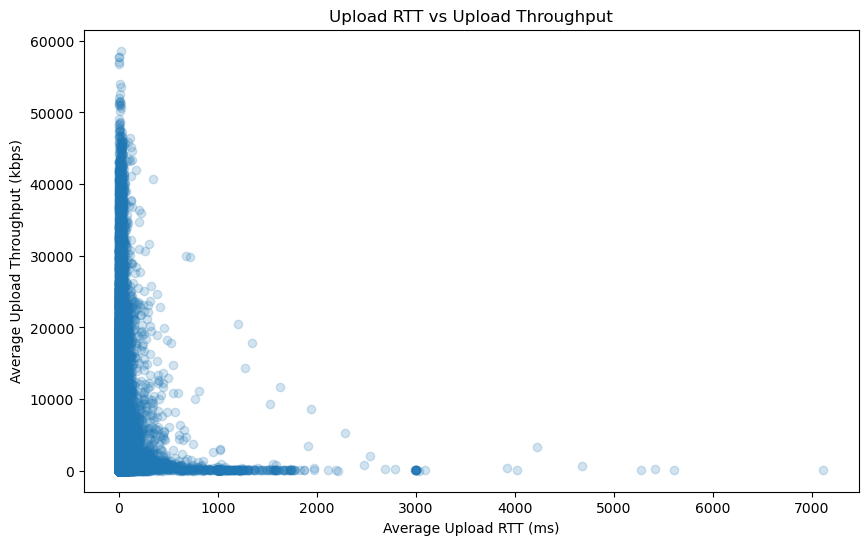

In [55]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df1["Avg RTT UL (ms)"],
    df1["Avg Bearer TP UL (kbps)"],
    alpha=0.2
)

plt.xlabel("Average Upload RTT (ms)")
plt.ylabel("Average Upload Throughput (kbps)")
plt.title("Upload RTT vs Upload Throughput")

plt.show()

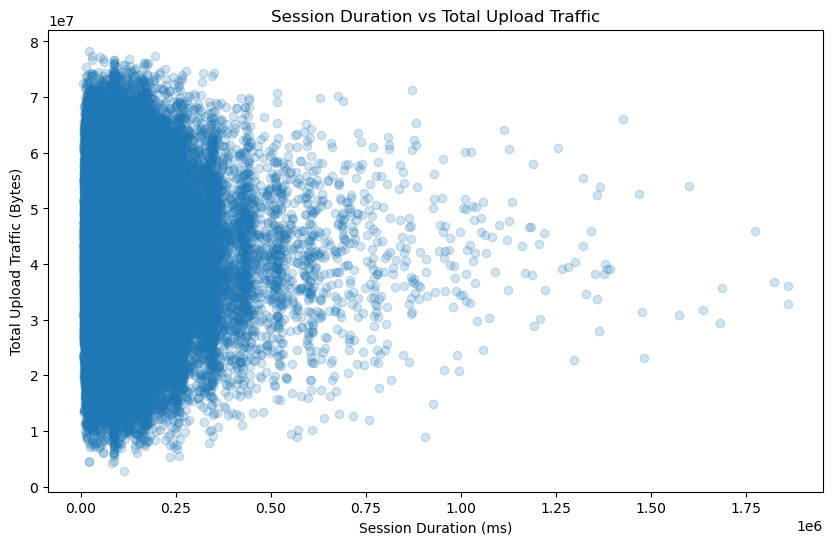

In [56]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df1["Dur. (ms)"],
    df1["Total UL (Bytes)"],
    alpha=0.2
)

plt.xlabel("Session Duration (ms)")
plt.ylabel("Total Upload Traffic (Bytes)")
plt.title("Session Duration vs Total Upload Traffic")

plt.show()

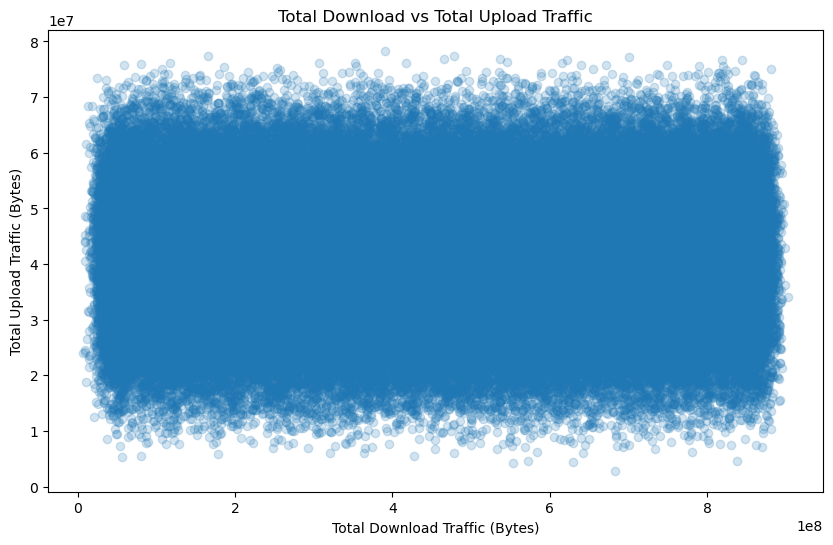

In [57]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df1["Total DL (Bytes)"],
    df1["Total UL (Bytes)"],
    alpha=0.2
)

plt.xlabel("Total Download Traffic (Bytes)")
plt.ylabel("Total Upload Traffic (Bytes)")
plt.title("Total Download vs Total Upload Traffic")

plt.show()

In [58]:
correlation_matrix = df1[numeric_analysis_cols].corr()

correlation_matrix.head()

,Start ms,End ms,Dur. (ms),Avg RTT DL (ms),Avg RTT UL (ms),Avg Bearer TP DL (kbps),Avg Bearer TP UL (kbps),TCP DL Retrans. Vol (Bytes),TCP UL Retrans. Vol (Bytes),DL TP < 50 Kbps (%),...,Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
Start ms,1.000000,0.122036,0.001216,0.002769,-0.001983,-0.000384,-0.001199,2.274035e-08,-0.003615,0.000380,...,-0.001446,0.001713,-0.001995,-0.002596,-0.004414,-0.002623,-0.003948,0.003605,-0.000043,-0.004471
End ms,0.122036,1.000000,-0.001168,-0.004560,-0.002722,0.000716,0.000659,4.583771e-03,-0.003412,-0.003833,...,-0.003412,-0.003389,0.003965,-0.001009,-0.004857,0.000926,0.002638,0.002721,-0.000519,-0.004857
Dur. (ms),0.001216,-0.001168,1.000000,-0.052373,-0.003049,-0.165732,-0.114342,1.857117e-02,0.006415,0.197470,...,0.003889,0.002308,-0.002032,-0.005257,0.000726,0.001593,-0.000362,0.001355,-0.000788,0.000793
Avg RTT DL (ms),0.002769,-0.004560,-0.052373,1.000000,0.008275,-0.022230,-0.011001,-4.603737e-03,-0.001892,-0.009352,...,-0.002140,0.005375,-0.000863,-0.006110,-0.002842,-0.008987,-0.001643,0.002278,-0.002882,-0.002926
Avg RTT UL (ms),-0.001983,-0.002722,-0.003049,0.008275,1.000000,0.054324,0.042763,2.568197e-02,0.034819,-0.050807,...,-0.001945,0.001352,-0.000580,0.000738,0.002851,0.002260,0.000110,-0.001393,0.001784,0.002780


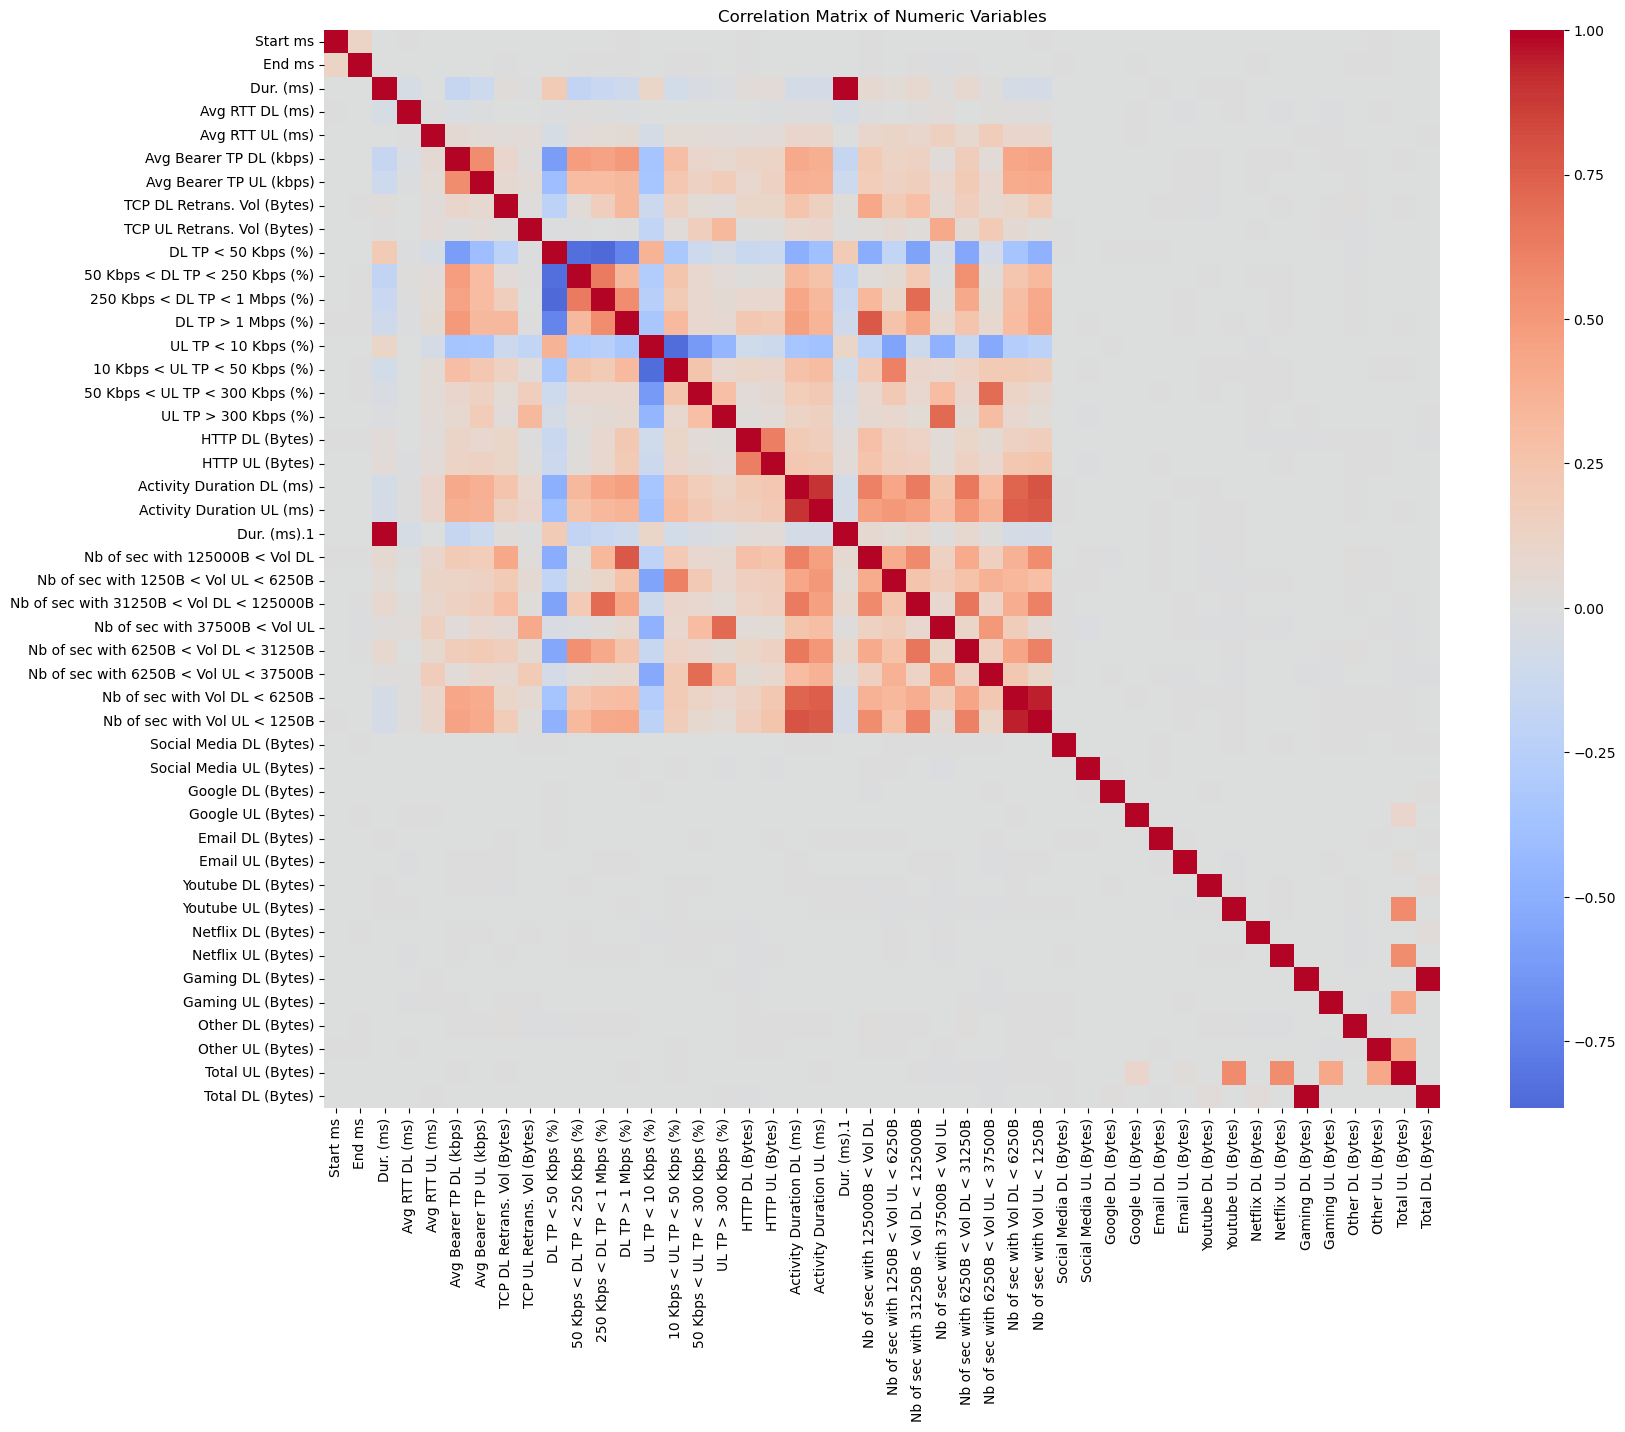

In [59]:
plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numeric Variables")
plt.show()

In [60]:
corr_pairs = correlation_matrix.where(
    ~np.eye(correlation_matrix.shape[0], dtype=bool)
).stack()

strongest_correlations = (
    corr_pairs
    .abs()
    .sort_values(ascending=False)
    .head(20)
)

strongest_correlations

Dur. (ms).1                      Dur. (ms)                          1.000000
Dur. (ms)                        Dur. (ms).1                        1.000000
Total DL (Bytes)                 Gaming DL (Bytes)                  0.999131
Gaming DL (Bytes)                Total DL (Bytes)                   0.999131
Nb of sec with Vol UL < 1250B    Nb of sec with Vol DL < 6250B      0.947163
Nb of sec with Vol DL < 6250B    Nb of sec with Vol UL < 1250B      0.947163
Activity Duration UL (ms)        Activity Duration DL (ms)          0.904760
Activity Duration DL (ms)        Activity Duration UL (ms)          0.904760
250 Kbps < DL TP < 1 Mbps (%)    DL TP < 50 Kbps (%)                0.865200
DL TP < 50 Kbps (%)              250 Kbps < DL TP < 1 Mbps (%)      0.865200
10 Kbps < UL TP < 50 Kbps (%)    UL TP < 10 Kbps (%)                0.847482
UL TP < 10 Kbps (%)              10 Kbps < UL TP < 50 Kbps (%)      0.847482
50 Kbps < DL TP < 250 Kbps (%)   DL TP < 50 Kbps (%)                0.843084

In [61]:
df1.columns.tolist()


['Bearer Id',
 'Start',
 'Start ms',
 'End',
 'End ms',
 'Dur. (ms)',
 'IMSI',
 'MSISDN/Number',
 'IMEI',
 'Last Location Name',
 'Avg RTT DL (ms)',
 'Avg RTT UL (ms)',
 'Avg Bearer TP DL (kbps)',
 'Avg Bearer TP UL (kbps)',
 'TCP DL Retrans. Vol (Bytes)',
 'TCP UL Retrans. Vol (Bytes)',
 'DL TP < 50 Kbps (%)',
 '50 Kbps < DL TP < 250 Kbps (%)',
 '250 Kbps < DL TP < 1 Mbps (%)',
 'DL TP > 1 Mbps (%)',
 'UL TP < 10 Kbps (%)',
 '10 Kbps < UL TP < 50 Kbps (%)',
 '50 Kbps < UL TP < 300 Kbps (%)',
 'UL TP > 300 Kbps (%)',
 'HTTP DL (Bytes)',
 'HTTP UL (Bytes)',
 'Activity Duration DL (ms)',
 'Activity Duration UL (ms)',
 'Dur. (ms).1',
 'Handset Manufacturer',
 'Handset Type',
 'Nb of sec with 125000B < Vol DL',
 'Nb of sec with 1250B < Vol UL < 6250B',
 'Nb of sec with 31250B < Vol DL < 125000B',
 'Nb of sec with 37500B < Vol UL',
 'Nb of sec with 6250B < Vol DL < 31250B',
 'Nb of sec with 6250B < Vol UL < 37500B',
 'Nb of sec with Vol DL < 6250B',
 'Nb of sec with Vol UL < 1250B',
 'Socia

In [62]:
top_10_handsets = (
    df1["Handset Type"]
    .value_counts()
    .head(10)
)

top_10_handsets


Handset Type
Huawei B528S-23A                19727
Apple iPhone 6S (A1688)          9413
Apple iPhone 6 (A1586)           9012
undefined                        8931
Apple iPhone 7 (A1778)           6304
Apple iPhone Se (A1723)          5176
Apple iPhone 8 (A1905)           4985
Apple iPhone Xr (A2105)          4562
Samsung Galaxy S8 (Sm-G950F)     4480
Apple iPhone X (A1901)           3810
Name: count, dtype: int64

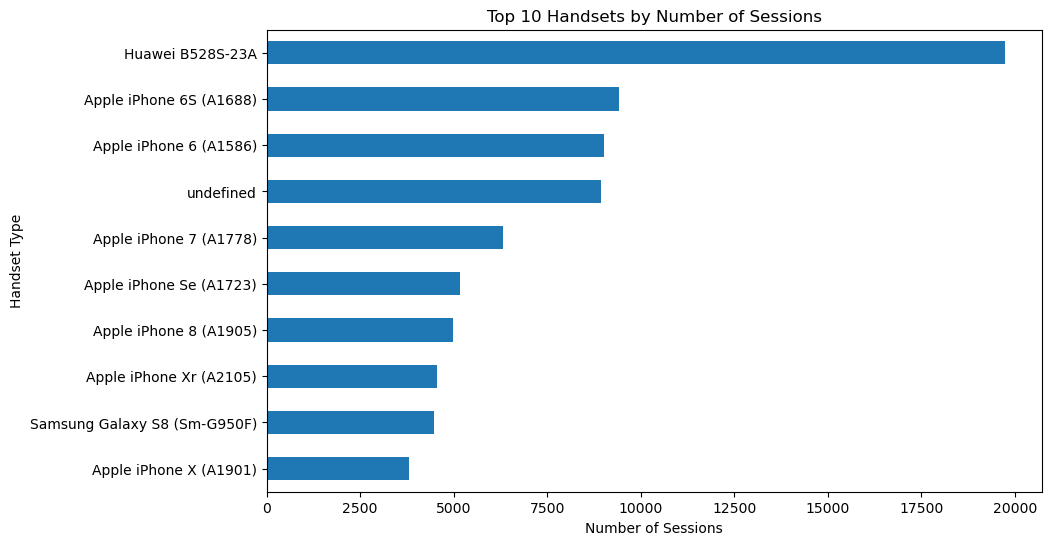

In [63]:
plt.figure(figsize=(10, 6))

top_10_handsets.sort_values().plot(kind="barh")

plt.xlabel("Number of Sessions")
plt.ylabel("Handset Type")
plt.title("Top 10 Handsets by Number of Sessions")

plt.show()

In [64]:
top_3_manufacturers = (
    df1["Handset Manufacturer"]
    .value_counts()
    .head(3)
)

top_3_manufacturers

Handset Manufacturer
Apple      59464
Samsung    40579
Huawei     34366
Name: count, dtype: int64

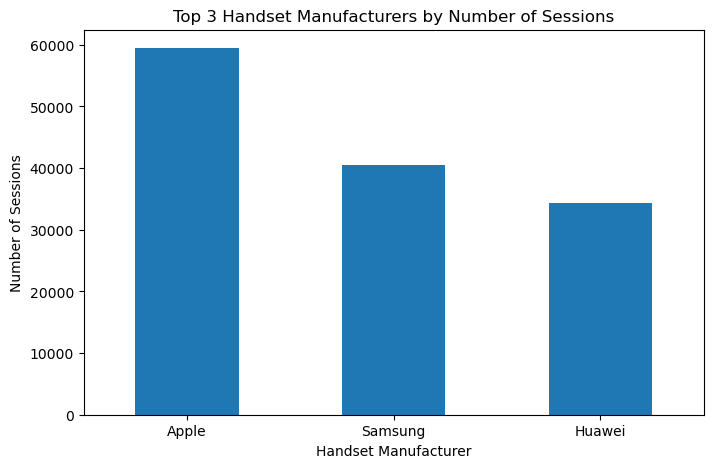

In [65]:
plt.figure(figsize=(8, 5))

top_3_manufacturers.plot(kind="bar")

plt.xlabel("Handset Manufacturer")
plt.ylabel("Number of Sessions")
plt.title("Top 3 Handset Manufacturers by Number of Sessions")

plt.xticks(rotation=0)
plt.show()

In [66]:
top_5_per_manufacturer = {}

for manufacturer in top_3_manufacturers.index:
    top_5_per_manufacturer[manufacturer] = (
        df1[df1["Handset Manufacturer"] == manufacturer]["Handset Type"]
        .value_counts()
        .head(5)
    )

top_5_per_manufacturer

{'Apple': Handset Type
 Apple iPhone 6S (A1688)    9413
 Apple iPhone 6 (A1586)     9012
 Apple iPhone 7 (A1778)     6304
 Apple iPhone Se (A1723)    5176
 Apple iPhone 8 (A1905)     4985
 Name: count, dtype: int64,
 'Samsung': Handset Type
 Samsung Galaxy S8 (Sm-G950F)    4480
 Samsung Galaxy A5 Sm-A520F      3708
 Samsung Galaxy J5 (Sm-J530)     3682
 Samsung Galaxy J3 (Sm-J330)     3464
 Samsung Galaxy S7 (Sm-G930X)    3176
 Name: count, dtype: int64,
 'Huawei': Handset Type
 Huawei B528S-23A                  19727
 Huawei E5180                       2074
 Huawei P20 Lite Huawei Nova 3E     2018
 Huawei P20                         1479
 Huawei Y6 2018                      997
 Name: count, dtype: int64}

In [67]:
for manufacturer, handsets in top_5_per_manufacturer.items():
    print(f"\n{manufacturer}")
    print(handsets)


Apple
Handset Type
Apple iPhone 6S (A1688)    9413
Apple iPhone 6 (A1586)     9012
Apple iPhone 7 (A1778)     6304
Apple iPhone Se (A1723)    5176
Apple iPhone 8 (A1905)     4985
Name: count, dtype: int64

Samsung
Handset Type
Samsung Galaxy S8 (Sm-G950F)    4480
Samsung Galaxy A5 Sm-A520F      3708
Samsung Galaxy J5 (Sm-J530)     3682
Samsung Galaxy J3 (Sm-J330)     3464
Samsung Galaxy S7 (Sm-G930X)    3176
Name: count, dtype: int64

Huawei
Handset Type
Huawei B528S-23A                  19727
Huawei E5180                       2074
Huawei P20 Lite Huawei Nova 3E     2018
Huawei P20                         1479
Huawei Y6 2018                      997
Name: count, dtype: int64


In [68]:
user_aggregation = (
    df1.groupby("MSISDN/Number")
      .agg(
          Number_of_Sessions=("Bearer Id", "count"),
          Total_Duration_ms=("Dur. (ms)", "sum"),
          Total_DL_Bytes=("Total DL (Bytes)", "sum"),
          Total_UL_Bytes=("Total UL (Bytes)", "sum")
      )
      .reset_index()
)

user_aggregation.head()

,MSISDN/Number,Number_of_Sessions,Total_Duration_ms,Total_DL_Bytes,Total_UL_Bytes
0,3.360100e+10,1,116720.0,8.426375e+08,36053108.0
1,3.360100e+10,1,181230.0,1.207552e+08,36104459.0
2,3.360100e+10,1,134969.0,5.566597e+08,39306820.0
3,3.360101e+10,1,49878.0,4.019932e+08,20327526.0
4,3.360101e+10,2,37104.0,1.363130e+09,94280527.0


In [69]:
user_aggregation["Total_Traffic_Bytes"] = (
    user_aggregation["Total_DL_Bytes"] +
    user_aggregation["Total_UL_Bytes"]
)

user_aggregation.head()

,MSISDN/Number,Number_of_Sessions,Total_Duration_ms,Total_DL_Bytes,Total_UL_Bytes,Total_Traffic_Bytes
0,3.360100e+10,1,116720.0,8.426375e+08,36053108.0,8.786906e+08
1,3.360100e+10,1,181230.0,1.207552e+08,36104459.0,1.568596e+08
2,3.360100e+10,1,134969.0,5.566597e+08,39306820.0,5.959665e+08
3,3.360101e+10,1,49878.0,4.019932e+08,20327526.0,4.223207e+08
4,3.360101e+10,2,37104.0,1.363130e+09,94280527.0,1.457411e+09


In [70]:
print("Number of unique users:", user_aggregation["MSISDN/Number"].nunique())
print("User aggregation shape:", user_aggregation.shape)

Number of unique users: 106856
User aggregation shape: (106856, 6)


In [71]:
top_10_users = (
    user_aggregation
    .sort_values("Total_Traffic_Bytes", ascending=False)
    .head(10)
)

top_10_users

,MSISDN/Number,Number_of_Sessions,Total_Duration_ms,Total_DL_Bytes,Total_UL_Bytes,Total_Traffic_Bytes
6437,3.361489e+10,17,9966898.0,8.156743e+09,689483001.0,8.846226e+09
92923,3.376054e+10,15,9279434.0,7.811295e+09,703478581.0,8.514774e+09
13180,3.362578e+10,17,18553754.0,7.770043e+09,729577380.0,8.499621e+09
13526,3.362632e+10,18,8791927.0,7.301517e+09,669650721.0,7.971167e+09
76363,3.367588e+10,15,4865947.0,7.309542e+09,581568792.0,7.891111e+09
37052,3.365973e+10,16,4035428.0,7.081602e+09,624260321.0,7.705863e+09
63028,3.366646e+10,11,4536757.0,6.903440e+09,405060976.0,7.308501e+09
92577,3.376041e+10,12,5321667.0,6.610852e+09,521518890.0,7.132371e+09
57241,3.366471e+10,11,2927785.0,6.400774e+09,471244453.0,6.872018e+09
86455,3.369879e+10,11,5169128.0,6.010556e+09,530343105.0,6.540899e+09


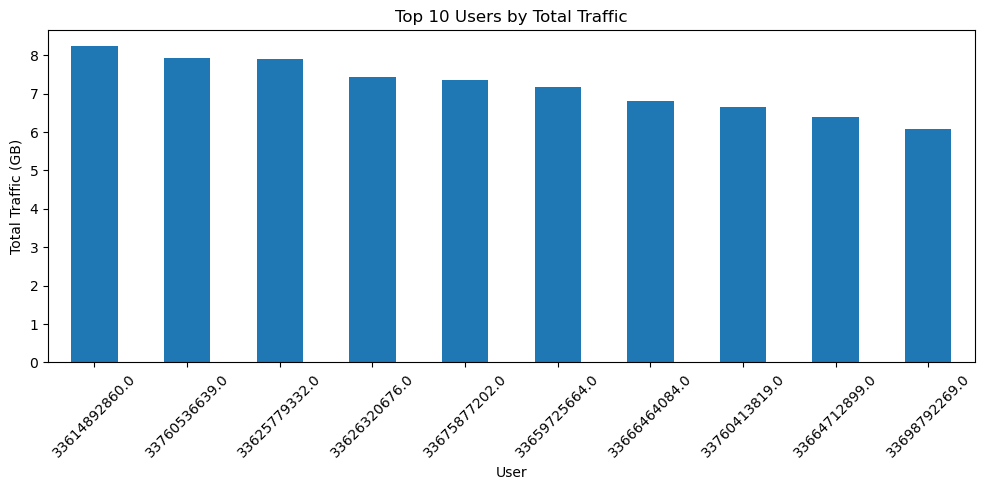

In [72]:
top_10_users = top_10_users.copy()

top_10_users["Total_Traffic_GB"] = (
    top_10_users["Total_Traffic_Bytes"] / (1024 ** 3)
)

top_10_users.plot(
    x="MSISDN/Number",
    y="Total_Traffic_GB",
    kind="bar",
    figsize=(10, 5),
    legend=False
)

plt.title("Top 10 Users by Total Traffic")
plt.xlabel("User")
plt.ylabel("Total Traffic (GB)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [73]:
top_10_session_users = (
    user_aggregation
    .sort_values("Number_of_Sessions", ascending=False)
    .head(10)
)

top_10_session_users[
    ["MSISDN/Number", "Number_of_Sessions", "Total_Traffic_Bytes"]
]

,MSISDN/Number,Number_of_Sessions,Total_Traffic_Bytes
13526,3.362632e+10,18,7.971167e+09
13180,3.362578e+10,17,8.499621e+09
6437,3.361489e+10,17,8.846226e+09
37052,3.365973e+10,16,7.705863e+09
92923,3.376054e+10,15,8.514774e+09
76363,3.367588e+10,15,7.891111e+09
65118,3.366716e+10,13,5.618394e+09
1279,3.360452e+10,12,5.487855e+09
13994,3.362708e+10,12,5.754731e+09
666,3.360313e+10,12,4.976195e+09


In [74]:
user_summary = user_aggregation[
    [
        "MSISDN/Number",
        "Number_of_Sessions",
        "Total_Duration_ms",
        "Total_Traffic_Bytes"
    ]
]

user_summary.describe()

,MSISDN/Number,Number_of_Sessions,Total_Duration_ms,Total_Traffic_Bytes
count,1.068560e+05,106856.000000,1.068560e+05,1.068560e+05
mean,4.511474e+10,1.389777,1.461672e+05,6.909621e+08
std,2.889423e+12,0.809863,1.863587e+05,4.910559e+08
min,3.360100e+10,0.000000,7.142000e+03,3.324901e+07
25%,3.365088e+10,1.000000,7.130800e+04,3.585499e+08
50%,3.366365e+10,1.000000,1.027400e+05,6.179231e+08
75%,3.368344e+10,2.000000,1.727990e+05,8.574351e+08
max,8.823971e+14,18.000000,1.855375e+07,8.846226e+09


In [75]:
engagement_metrics = user_aggregation[
    [
        "MSISDN/Number",
        "Number_of_Sessions",
        "Total_Duration_ms",
        "Total_Traffic_Bytes"
    ]
].copy()

engagement_metrics.head()

,MSISDN/Number,Number_of_Sessions,Total_Duration_ms,Total_Traffic_Bytes
0,3.360100e+10,1,116720.0,8.786906e+08
1,3.360100e+10,1,181230.0,1.568596e+08
2,3.360100e+10,1,134969.0,5.959665e+08
3,3.360101e+10,1,49878.0,4.223207e+08
4,3.360101e+10,2,37104.0,1.457411e+09


In [76]:
scaler = MinMaxScaler()

engagement_metrics[
    ["Sessions_Score", "Duration_Score", "Traffic_Score"]
] = scaler.fit_transform(
    engagement_metrics[
        ["Number_of_Sessions", "Total_Duration_ms", "Total_Traffic_Bytes"]
    ]
)

engagement_metrics.head()

,MSISDN/Number,Number_of_Sessions,Total_Duration_ms,Total_Traffic_Bytes,Sessions_Score,Duration_Score,Traffic_Score
0,3.360100e+10,1,116720.0,8.786906e+08,0.055556,0.005908,0.095931
1,3.360100e+10,1,181230.0,1.568596e+08,0.055556,0.009387,0.014026
2,3.360100e+10,1,134969.0,5.959665e+08,0.055556,0.006892,0.063851
3,3.360101e+10,1,49878.0,4.223207e+08,0.055556,0.002304,0.044148
4,3.360101e+10,2,37104.0,1.457411e+09,0.111111,0.001615,0.161598


In [77]:
engagement_metrics["Engagement_Score"] = (
    engagement_metrics["Sessions_Score"] +
    engagement_metrics["Duration_Score"] +
    engagement_metrics["Traffic_Score"]
) / 3

engagement_metrics.head()

most_engaged = (
    engagement_metrics
    .sort_values("Engagement_Score", ascending=False)
    .head(10)
)

least_engaged = (
    engagement_metrics
    .sort_values("Engagement_Score")
    .head(10)
)

print("Most Engaged Users:")
display(most_engaged)

print("\nLeast Engaged Users:")
display(least_engaged)

Most Engaged Users:


,MSISDN/Number,Number_of_Sessions,Total_Duration_ms,Total_Traffic_Bytes,Sessions_Score,Duration_Score,Traffic_Score,Engagement_Score
13180,3.362578e+10,17,18553754.0,8.499621e+09,0.944444,1.000000,0.960671,0.968372
6437,3.361489e+10,17,9966898.0,8.846226e+09,0.944444,0.537012,1.000000,0.827152
13526,3.362632e+10,18,8791927.0,7.971167e+09,1.000000,0.473660,0.900708,0.791456
92923,3.376054e+10,15,9279434.0,8.514774e+09,0.833333,0.499945,0.962390,0.765223
76363,3.367588e+10,15,4865947.0,7.891111e+09,0.833333,0.261978,0.891624,0.662312
37052,3.365973e+10,16,4035428.0,7.705863e+09,0.888889,0.217198,0.870604,0.658897
65118,3.366716e+10,13,8744914.0,5.618394e+09,0.722222,0.471125,0.633741,0.609029
92577,3.376041e+10,12,5321667.0,7.132371e+09,0.666667,0.286550,0.805530,0.586249
63028,3.366646e+10,11,4536757.0,7.308501e+09,0.611111,0.244229,0.825516,0.560285
86455,3.369879e+10,11,5169128.0,6.540899e+09,0.611111,0.278325,0.738417,0.542618



Least Engaged Users:


,MSISDN/Number,Number_of_Sessions,Total_Duration_ms,Total_Traffic_Bytes,Sessions_Score,Duration_Score,Traffic_Score,Engagement_Score
45262,3.366171e+10,0,22650.0,52944613.0,0.0,0.000836,0.002235,0.001024
106021,3.378587e+10,0,25204.0,72296262.0,0.0,0.000974,0.004431,0.001802
106294,3.378686e+10,0,18265.0,84771017.0,0.0,0.000600,0.005846,0.002149
18335,3.363626e+10,0,54393.0,78630710.0,0.0,0.002548,0.005149,0.002566
8195,3.361780e+10,0,24338.0,93354355.0,0.0,0.000927,0.006820,0.002582
314,3.360182e+10,0,47425.0,83190181.0,0.0,0.002172,0.005667,0.002613
79341,3.368184e+10,0,12427.0,105280673.0,0.0,0.000285,0.008173,0.002819
91439,3.375807e+10,0,9159.0,108201448.0,0.0,0.000109,0.008505,0.002871
76187,3.367552e+10,0,10951.0,108532689.0,0.0,0.000205,0.008542,0.002916
72751,3.366969e+10,0,8244.0,111644471.0,0.0,0.000059,0.008895,0.002985


In [78]:
Number_of_Sessions=("Bearer Id", "count")
user_aggregation["Number_of_Sessions"] = (
    df1.groupby("MSISDN/Number").size().values
)

session_counts = (
    df1.groupby("MSISDN/Number")
      .size()
      .rename("Number_of_Sessions")
)

user_aggregation["Number_of_Sessions"] = (
    user_aggregation["MSISDN/Number"]
    .map(session_counts)
)



In [79]:
user_aggregation["Number_of_Sessions"].describe()

count    106856.000000
mean          1.393792
std           0.806022
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          18.000000
Name: Number_of_Sessions, dtype: float64

In [80]:
engagement_metrics["Number_of_Sessions"] = (
    engagement_metrics["MSISDN/Number"]
    .map(session_counts)
)

engagement_metrics[
    ["Sessions_Score", "Duration_Score", "Traffic_Score"]
] = scaler.fit_transform(
    engagement_metrics[
        ["Number_of_Sessions", "Total_Duration_ms", "Total_Traffic_Bytes"]
    ]
)

engagement_metrics["Engagement_Score"] = (
    engagement_metrics["Sessions_Score"] +
    engagement_metrics["Duration_Score"] +
    engagement_metrics["Traffic_Score"]
) / 3

In [81]:
most_engaged = (
    engagement_metrics
    .sort_values("Engagement_Score", ascending=False)
    .head(10)
)

least_engaged = (
    engagement_metrics
    .sort_values("Engagement_Score")
    .head(10)
)

print("Most Engaged Users:")
display(most_engaged)

print("\nLeast Engaged Users:")
display(least_engaged)

Most Engaged Users:


,MSISDN/Number,Number_of_Sessions,Total_Duration_ms,Total_Traffic_Bytes,Sessions_Score,Duration_Score,Traffic_Score,Engagement_Score
13180,3.362578e+10,17,18553754.0,8.499621e+09,0.941176,1.000000,0.960671,0.967282
6437,3.361489e+10,17,9966898.0,8.846226e+09,0.941176,0.537012,1.000000,0.826063
13526,3.362632e+10,18,8791927.0,7.971167e+09,1.000000,0.473660,0.900708,0.791456
92923,3.376054e+10,15,9279434.0,8.514774e+09,0.823529,0.499945,0.962390,0.761955
76363,3.367588e+10,15,4865947.0,7.891111e+09,0.823529,0.261978,0.891624,0.659044
37052,3.365973e+10,16,4035428.0,7.705863e+09,0.882353,0.217198,0.870604,0.656718
65118,3.366716e+10,13,8744914.0,5.618394e+09,0.705882,0.471125,0.633741,0.603583
92577,3.376041e+10,12,5321667.0,7.132371e+09,0.647059,0.286550,0.805530,0.579713
63028,3.366646e+10,11,4536757.0,7.308501e+09,0.588235,0.244229,0.825516,0.552660
86455,3.369879e+10,11,5169128.0,6.540899e+09,0.588235,0.278325,0.738417,0.534992



Least Engaged Users:


,MSISDN/Number,Number_of_Sessions,Total_Duration_ms,Total_Traffic_Bytes,Sessions_Score,Duration_Score,Traffic_Score,Engagement_Score
11211,3.362260e+10,1,19764.0,42597763.0,0.0,0.000681,0.001061,0.000580
14703,3.362833e+10,1,13755.0,46047479.0,0.0,0.000357,0.001452,0.000603
34696,3.365920e+10,1,42856.0,33249009.0,0.0,0.001926,0.000000,0.000642
76161,3.367548e+10,1,38371.0,38022357.0,0.0,0.001684,0.000542,0.000742
104592,3.378224e+10,1,8741.0,52870808.0,0.0,0.000086,0.002226,0.000771
19610,3.364136e+10,1,27772.0,46156035.0,0.0,0.001112,0.001465,0.000859
63166,3.366652e+10,1,16036.0,53506635.0,0.0,0.000480,0.002299,0.000926
1508,3.360575e+10,1,11181.0,56536117.0,0.0,0.000218,0.002642,0.000953
45262,3.366171e+10,1,22650.0,52944613.0,0.0,0.000836,0.002235,0.001024
24510,3.365038e+10,1,8550.0,60132191.0,0.0,0.000076,0.003050,0.001042


In [82]:

clustering_data = engagement_metrics[
    ["Sessions_Score", "Duration_Score", "Traffic_Score"]
].copy()

clustering_data.head()

,Sessions_Score,Duration_Score,Traffic_Score
0,0.000000,0.005908,0.095931
1,0.000000,0.009387,0.014026
2,0.000000,0.006892,0.063851
3,0.000000,0.002304,0.044148
4,0.058824,0.001615,0.161598


In [83]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

engagement_metrics["Engagement_Cluster"] = kmeans.fit_predict(
    clustering_data
)

engagement_metrics.head()

  File "C:\Users\Sidd\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Sidd\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Sidd\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Sidd\anaconda3\Lib\subprocess.py",

,MSISDN/Number,Number_of_Sessions,Total_Duration_ms,Total_Traffic_Bytes,Sessions_Score,Duration_Score,Traffic_Score,Engagement_Score,Engagement_Cluster
0,3.360100e+10,1,116720.0,8.786906e+08,0.000000,0.005908,0.095931,0.033947,2
1,3.360100e+10,1,181230.0,1.568596e+08,0.000000,0.009387,0.014026,0.007804,2
2,3.360100e+10,1,134969.0,5.959665e+08,0.000000,0.006892,0.063851,0.023581,2
3,3.360101e+10,1,49878.0,4.223207e+08,0.000000,0.002304,0.044148,0.015484,2
4,3.360101e+10,2,37104.0,1.457411e+09,0.058824,0.001615,0.161598,0.074012,0


In [84]:
cluster_summary = (
    engagement_metrics
    .groupby("Engagement_Cluster")
    [["Number_of_Sessions", "Total_Duration_ms", "Total_Traffic_Bytes",
      "Engagement_Score"]]
    .mean()
)

cluster_summary

,Number_of_Sessions,Total_Duration_ms,Total_Traffic_Bytes,Engagement_Score
Engagement_Cluster,,,,
0,2.177085,213675.530099,1.126061e+09,0.068126
1,4.253211,570596.777174,2.283232e+09,0.159016
2,1.042285,106995.244791,4.955131e+08,0.020108


In [85]:
cluster_labels = {
    2: "Low Engagement",
    0: "Medium Engagement",
    1: "High Engagement"
}

engagement_metrics["Engagement_Level"] = (
    engagement_metrics["Engagement_Cluster"]
    .map(cluster_labels)
)

engagement_metrics["Engagement_Level"].value_counts()

Engagement_Level
Low Engagement       81163
Medium Engagement    21645
High Engagement       4048
Name: count, dtype: int64

In [86]:
engagement_metrics.groupby("Engagement_Level")[
    ["Number_of_Sessions", "Total_Duration_ms", "Total_Traffic_Bytes", "Engagement_Score"]
].mean().sort_values("Engagement_Score")

,Number_of_Sessions,Total_Duration_ms,Total_Traffic_Bytes,Engagement_Score
Engagement_Level,,,,
Low Engagement,1.042285,106995.244791,4.955131e+08,0.020108
Medium Engagement,2.177085,213675.530099,1.126061e+09,0.068126
High Engagement,4.253211,570596.777174,2.283232e+09,0.159016


In [87]:
engagement_counts = (
    engagement_metrics["Engagement_Level"]
    .value_counts()
    .reindex(["Low Engagement", "Medium Engagement", "High Engagement"])
)

engagement_counts

Engagement_Level
Low Engagement       81163
Medium Engagement    21645
High Engagement       4048
Name: count, dtype: int64

<Axes: title={'center': 'Users by Engagement Level'}, xlabel='Engagement Level', ylabel='Number of Users'>

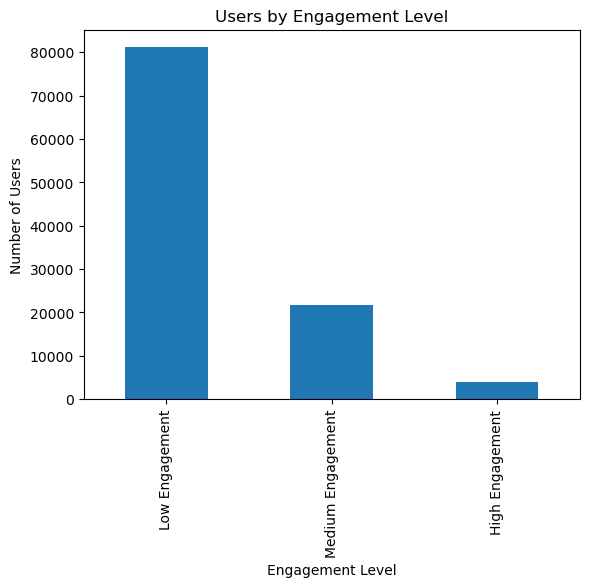

In [88]:
engagement_counts.plot(
    kind="bar",
    title="Users by Engagement Level",
    xlabel="Engagement Level",
    ylabel="Number of Users"
)

In [89]:
experience_metrics = (
    df1.groupby("MSISDN/Number")
      .agg(
          Avg_TCP_DL_Retrans=("TCP DL Retrans. Vol (Bytes)", "mean"),
          Avg_TCP_UL_Retrans=("TCP UL Retrans. Vol (Bytes)", "mean"),
          Avg_RTT_DL=("Avg RTT DL (ms)", "mean"),
          Avg_RTT_UL=("Avg RTT UL (ms)", "mean"),
          Avg_Throughput_DL=("Avg Bearer TP DL (kbps)", "mean"),
          Avg_Throughput_UL=("Avg Bearer TP UL (kbps)", "mean")
      )
      .reset_index()
)

experience_metrics.head()


,MSISDN/Number,Avg_TCP_DL_Retrans,Avg_TCP_UL_Retrans,Avg_RTT_DL,Avg_RTT_UL,Avg_Throughput_DL,Avg_Throughput_UL
0,3.360100e+10,NaN,NaN,46.0,0.0,37.0,39.0
1,3.360100e+10,NaN,NaN,30.0,1.0,48.0,51.0
2,3.360100e+10,NaN,NaN,NaN,NaN,48.0,49.0
3,3.360101e+10,1066.0,NaN,69.0,15.0,204.0,44.0
4,3.360101e+10,9349630.0,21202.0,57.0,2.5,20197.5,8224.5


In [90]:
experience_stats = experience_metrics.drop(
    columns=["MSISDN/Number"]
).describe().T

experience_stats["skewness"] = experience_metrics.drop(
    columns=["MSISDN/Number"]
).skew()

experience_stats[
    ["count", "mean", "50%", "std", "min", "max", "skewness"]
]

,count,mean,50%,std,min,max,skewness
Avg_TCP_DL_Retrans,48524.0,1.685339e+07,425698.0,1.465428e+08,2.0,4.289488e+09,17.598769
Avg_TCP_UL_Retrans,41726.0,6.240082e+05,19222.6,2.083145e+07,1.0,2.455600e+09,84.941803
Avg_RTT_DL,88320.0,1.191829e+02,45.0,6.423543e+02,0.0,9.692300e+04,58.303311
Avg_RTT_UL,88333.0,1.677113e+01,5.0,8.410922e+01,0.0,7.120000e+03,30.102078
Avg_Throughput_DL,106856.0,1.163400e+04,110.0,2.060573e+04,0.0,2.644480e+05,2.640009
Avg_Throughput_UL,106856.0,1.518879e+03,75.5,3.912109e+03,0.0,5.861300e+04,4.840377


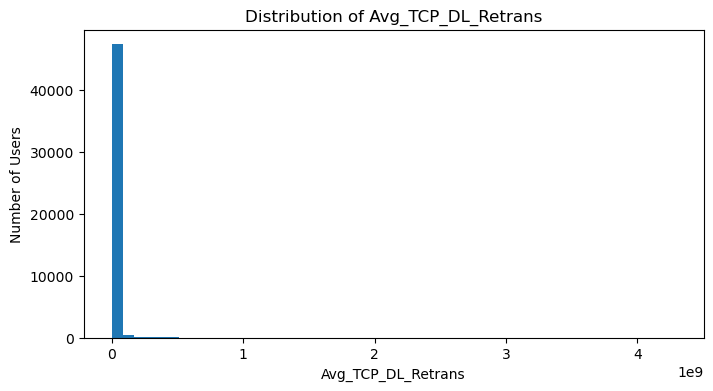

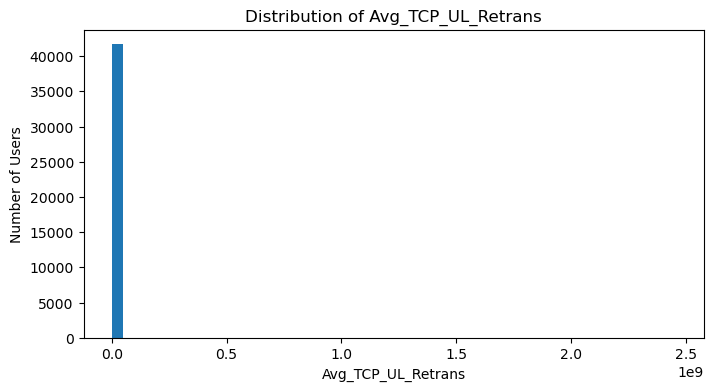

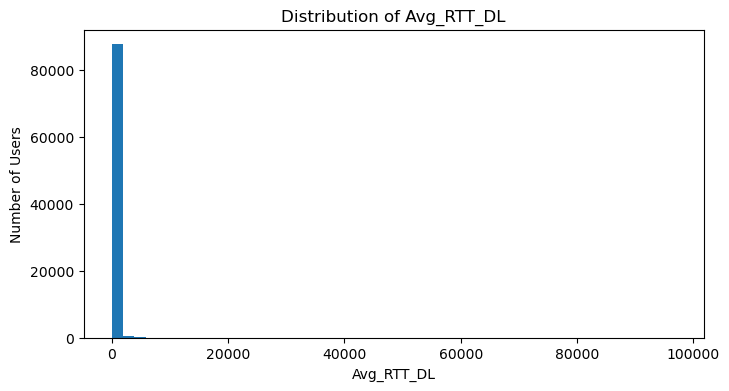

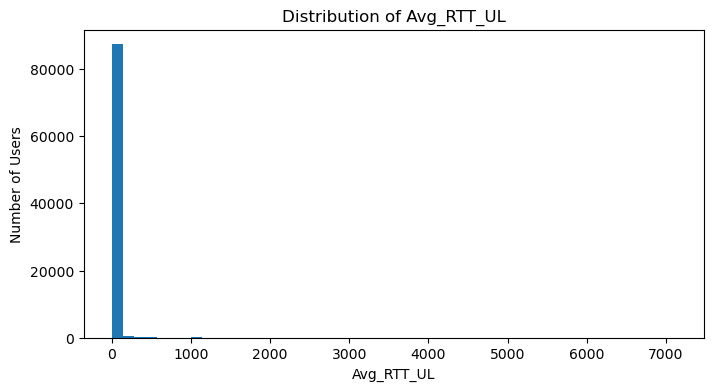

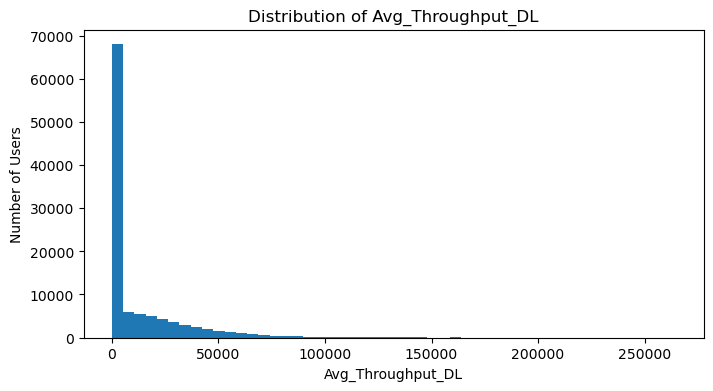

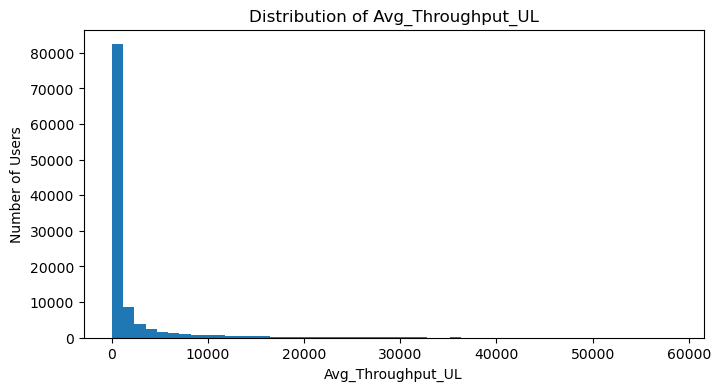

In [91]:

experience_columns = [
    "Avg_TCP_DL_Retrans",
    "Avg_TCP_UL_Retrans",
    "Avg_RTT_DL",
    "Avg_RTT_UL",
    "Avg_Throughput_DL",
    "Avg_Throughput_UL"
]

for col in experience_columns:
    plt.figure(figsize=(8, 4))
    plt.hist(experience_metrics[col].dropna(), bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Users")
    plt.show()

In [92]:
experience_scoring = experience_metrics.copy()

for col in experience_columns:
    upper_limit = experience_scoring[col].quantile(0.99)
    experience_scoring[col] = experience_scoring[col].clip(upper=upper_limit)

experience_scoring.head()

,MSISDN/Number,Avg_TCP_DL_Retrans,Avg_TCP_UL_Retrans,Avg_RTT_DL,Avg_RTT_UL,Avg_Throughput_DL,Avg_Throughput_UL
0,3.360100e+10,NaN,NaN,46.0,0.0,37.0,39.0
1,3.360100e+10,NaN,NaN,30.0,1.0,48.0,51.0
2,3.360100e+10,NaN,NaN,NaN,NaN,48.0,49.0
3,3.360101e+10,1066.0,NaN,69.0,15.0,204.0,44.0
4,3.360101e+10,9349630.0,21202.0,57.0,2.5,20197.5,8224.5


In [93]:
experience_scaler = MinMaxScaler()

experience_scoring[
    [
        "TCP_DL_Score",
        "TCP_UL_Score",
        "RTT_DL_Score",
        "RTT_UL_Score",
        "Throughput_DL_Score",
        "Throughput_UL_Score"
    ]
] = experience_scaler.fit_transform(
    experience_scoring[
        [
            "Avg_TCP_DL_Retrans",
            "Avg_TCP_UL_Retrans",
            "Avg_RTT_DL",
            "Avg_RTT_UL",
            "Avg_Throughput_DL",
            "Avg_Throughput_UL"
        ]
    ]
)

# Invert metrics 
experience_scoring["TCP_DL_Score"] = 1 - experience_scoring["TCP_DL_Score"]
experience_scoring["TCP_UL_Score"] = 1 - experience_scoring["TCP_UL_Score"]
experience_scoring["RTT_DL_Score"] = 1 - experience_scoring["RTT_DL_Score"]
experience_scoring["RTT_UL_Score"] = 1 - experience_scoring["RTT_UL_Score"]

experience_scoring.head()

,MSISDN/Number,Avg_TCP_DL_Retrans,Avg_TCP_UL_Retrans,Avg_RTT_DL,Avg_RTT_UL,Avg_Throughput_DL,Avg_Throughput_UL,TCP_DL_Score,TCP_UL_Score,RTT_DL_Score,RTT_UL_Score,Throughput_DL_Score,Throughput_UL_Score
0,3.360100e+10,NaN,NaN,46.0,0.0,37.0,39.0,NaN,NaN,0.969136,1.000000,0.000411,0.001926
1,3.360100e+10,NaN,NaN,30.0,1.0,48.0,51.0,NaN,NaN,0.979872,0.993789,0.000533,0.002519
2,3.360100e+10,NaN,NaN,NaN,NaN,48.0,49.0,NaN,NaN,NaN,NaN,0.000533,0.002420
3,3.360101e+10,1066.0,NaN,69.0,15.0,204.0,44.0,0.999996,NaN,0.953705,0.906832,0.002267,0.002173
4,3.360101e+10,9349630.0,21202.0,57.0,2.5,20197.5,8224.5,0.966046,0.995531,0.961756,0.984472,0.224477,0.406152


In [94]:
experience_score_columns = [
    "TCP_DL_Score",
    "TCP_UL_Score",
    "RTT_DL_Score",
    "RTT_UL_Score",
    "Throughput_DL_Score",
    "Throughput_UL_Score"
]

experience_scoring["Experience_Score"] = (
    experience_scoring[experience_score_columns]
    .mean(axis=1, skipna=True)
)

experience_scoring[
    ["MSISDN/Number", "Experience_Score"]
].head()

,MSISDN/Number,Experience_Score
0,3.360100e+10,0.492868
1,3.360100e+10,0.494178
2,3.360100e+10,0.001477
3,3.360101e+10,0.572995
4,3.360101e+10,0.756406


In [95]:
experience_scoring["Experience_Score"].describe()

count    106856.000000
mean          0.493116
std           0.248336
min           0.000000
25%           0.483718
50%           0.495556
75%           0.672395
max           0.993375
Name: Experience_Score, dtype: float64

In [96]:
experience_scoring[
    ["MSISDN/Number", "Experience_Score"]
].sort_values(
    "Experience_Score",
    ascending=False
).head(10)

,MSISDN/Number,Experience_Score
18232,3.363554e+10,0.993375
91059,3.375344e+10,0.992857
18583,3.363724e+10,0.992139
53838,3.366375e+10,0.992022
26182,3.365076e+10,0.991493
29029,3.365802e+10,0.991355
10359,3.362118e+10,0.991084
19756,3.364187e+10,0.991022
70281,3.366885e+10,0.990905
94738,3.376131e+10,0.990524


In [97]:
bottom_experience_users = (
    experience_scoring[
        ["MSISDN/Number", "Experience_Score"]
    ]
    .sort_values("Experience_Score", ascending=True)
    .head(10)
)

bottom_experience_users

,MSISDN/Number,Experience_Score
28037,3.365185e+10,0.0
94815,3.376134e+10,0.0
9460,3.361983e+10,0.0
106814,3.378967e+10,0.0
73574,3.367056e+10,0.0
10649,3.362166e+10,0.0
93945,3.376100e+10,0.0
10911,3.362210e+10,0.0
2605,3.360875e+10,0.0
41946,3.366087e+10,0.0


In [98]:
experience_scoring[
    experience_scoring["MSISDN/Number"] == 3.365185e+10
][
    [
        "Avg_TCP_DL_Retrans",
        "Avg_TCP_UL_Retrans",
        "Avg_RTT_DL",
        "Avg_RTT_UL",
        "Avg_Throughput_DL",
        "Avg_Throughput_UL",
        "Experience_Score"
    ]
]

,Avg_TCP_DL_Retrans,Avg_TCP_UL_Retrans,Avg_RTT_DL,Avg_RTT_UL,Avg_Throughput_DL,Avg_Throughput_UL,Experience_Score


In [99]:
experience_scoring["Valid_Experience_Metrics"] = (
    experience_scoring[experience_score_columns]
    .notna()
    .sum(axis=1)
)

experience_scoring["Valid_Experience_Metrics"].value_counts().sort_index()

Valid_Experience_Metrics
2    18328
3      205
4    37632
5    11330
6    39361
Name: count, dtype: int64

In [100]:
experience_scoring["Experience_Level"] = pd.qcut(
    experience_scoring["Experience_Score"],
    q=3,
    labels=["Low Experience", "Medium Experience", "High Experience"],
    duplicates="drop"
)

experience_scoring["Experience_Level"].value_counts()

Experience_Level
Low Experience       35621
High Experience      35619
Medium Experience    35616
Name: count, dtype: int64

In [101]:
experience_summary = (
    experience_scoring
    .groupby("Experience_Level", observed=True)[
        [
            "Avg_TCP_DL_Retrans",
            "Avg_TCP_UL_Retrans",
            "Avg_RTT_DL",
            "Avg_RTT_UL",
            "Avg_Throughput_DL",
            "Avg_Throughput_UL",
            "Experience_Score"
        ]
    ]
    .mean()
)

experience_summary

,Avg_TCP_DL_Retrans,Avg_TCP_UL_Retrans,Avg_RTT_DL,Avg_RTT_UL,Avg_Throughput_DL,Avg_Throughput_UL,Experience_Score
Experience_Level,,,,,,,
Low Experience,3.525145e+07,1.508446e+06,105.679515,14.416616,315.013872,90.031979,0.228475
Medium Experience,1.319492e+07,3.185627e+05,106.092390,9.688138,3586.128776,407.797493,0.531629
High Experience,6.134982e+06,1.080673e+05,77.509239,15.191180,30248.910201,3847.776988,0.719261


In [102]:
satisfaction = engagement_metrics[
    ["MSISDN/Number", "Engagement_Score"]
].merge(
    experience_scoring[
        ["MSISDN/Number", "Experience_Score"]
    ],
    on="MSISDN/Number",
    how="inner"
)

satisfaction["Satisfaction_Score"] = (
    satisfaction["Engagement_Score"] +
    satisfaction["Experience_Score"]
) / 2

satisfaction.head()

,MSISDN/Number,Engagement_Score,Experience_Score,Satisfaction_Score
0,3.360100e+10,0.033947,0.492868,0.263407
1,3.360100e+10,0.007804,0.494178,0.250991
2,3.360100e+10,0.023581,0.001477,0.012529
3,3.360101e+10,0.015484,0.572995,0.294239
4,3.360101e+10,0.074012,0.756406,0.415209


In [103]:
satisfaction["Satisfaction_Level"] = pd.qcut(
    satisfaction["Satisfaction_Score"],
    q=3,
    labels=["Low Satisfaction", "Medium Satisfaction", "High Satisfaction"],
    duplicates="drop"
)

satisfaction["Satisfaction_Level"].value_counts()

Satisfaction_Level
Low Satisfaction       35619
High Satisfaction      35619
Medium Satisfaction    35618
Name: count, dtype: int64

In [104]:
satisfaction_summary = (
    satisfaction
    .groupby("Satisfaction_Level", observed=True)
    [
        [
            "Engagement_Score",
            "Experience_Score",
            "Satisfaction_Score"
        ]
    ]
    .mean()
)

satisfaction_summary

,Engagement_Score,Experience_Score,Satisfaction_Score
Satisfaction_Level,,,
Low Satisfaction,0.020141,0.230281,0.125211
Medium Satisfaction,0.033713,0.532325,0.283019
High Satisfaction,0.051436,0.716743,0.384089


In [105]:
satisfaction[
    [
        "Engagement_Score",
        "Experience_Score",
        "Satisfaction_Score"
    ]
].corr()

,Engagement_Score,Experience_Score,Satisfaction_Score
Engagement_Score,1.000000,0.185280,0.314418
Experience_Score,0.185280,1.000000,0.991104
Satisfaction_Score,0.314418,0.991104,1.000000


In [106]:
experience_clustering = experience_scoring[
    [
        "TCP_DL_Score",
        "TCP_UL_Score",
        "RTT_DL_Score",
        "RTT_UL_Score",
        "Throughput_DL_Score",
        "Throughput_UL_Score"
    ]
].copy()

experience_clustering = experience_clustering.dropna()

In [107]:
experience_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

experience_clustering["Experience_Cluster"] = (
    experience_kmeans.fit_predict(experience_clustering)
)

In [108]:
experience_clustering["Experience_Cluster"] = (
    experience_kmeans.fit_predict(experience_clustering)
)

In [109]:
experience_clustering["Experience_Cluster"].value_counts().sort_index()

Experience_Cluster
0    23684
1    11189
2     4488
Name: count, dtype: int64

In [110]:
experience_cluster_summary = (
    experience_clustering
    .groupby("Experience_Cluster")
    [
        [
            "TCP_DL_Score",
            "TCP_UL_Score",
            "RTT_DL_Score",
            "RTT_UL_Score",
            "Throughput_DL_Score",
            "Throughput_UL_Score"
        ]
    ]
    .mean()
)

experience_cluster_summary

,TCP_DL_Score,TCP_UL_Score,RTT_DL_Score,RTT_UL_Score,Throughput_DL_Score,Throughput_UL_Score
Experience_Cluster,,,,,,
0,0.982695,0.973997,0.877349,0.908167,0.143755,0.074557
1,0.940117,0.964629,0.949342,0.833897,0.536947,0.160804
2,0.912963,0.894086,0.945287,0.840258,0.549428,0.747807


In [111]:
experience_cluster_labels = {
    0: "Low Experience",
    1: "Medium Experience",
    2: "High Experience"
}

experience_clustering["Experience_Level"] = (
    experience_clustering["Experience_Cluster"]
    .map(experience_cluster_labels)
)

In [112]:
experience_clustering["Experience_Level"].value_counts()

Experience_Level
Low Experience       23684
Medium Experience    11189
High Experience       4488
Name: count, dtype: int64

In [113]:
experience_metrics[
    [
        "Avg_TCP_DL_Retrans",
        "Avg_TCP_UL_Retrans",
        "Avg_RTT_DL",
        "Avg_RTT_UL",
        "Avg_Throughput_DL",
        "Avg_Throughput_UL"
    ]
].describe()

,Avg_TCP_DL_Retrans,Avg_TCP_UL_Retrans,Avg_RTT_DL,Avg_RTT_UL,Avg_Throughput_DL,Avg_Throughput_UL
count,4.852400e+04,4.172600e+04,88320.000000,88333.000000,106856.000000,106856.000000
mean,1.685339e+07,6.240082e+05,119.182869,16.771129,11633.998253,1518.878793
std,1.465428e+08,2.083145e+07,642.354308,84.109221,20605.733177,3912.108899
min,2.000000e+00,1.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,2.613000e+04,4.252000e+03,32.000000,2.500000,43.000000,48.000000
50%,4.256980e+05,1.922260e+04,45.000000,5.000000,110.000000,75.500000
75%,3.202019e+06,7.731675e+04,70.000000,13.000000,16816.250000,1006.000000
max,4.289488e+09,2.455600e+09,96923.000000,7120.000000,264448.000000,58613.000000


In [114]:
experience_task32 = {}

metrics = [
    "Avg_TCP_DL_Retrans",
    "Avg_TCP_UL_Retrans",
    "Avg_RTT_DL",
    "Avg_RTT_UL",
    "Avg_Throughput_DL",
    "Avg_Throughput_UL"
]

for col in metrics:
    series = experience_metrics[col].dropna()

    experience_task32[col] = {
        "Top_10": series.nlargest(10).values,
        "Bottom_10": series.nsmallest(10).values,
        "Most_Frequent_10": series.value_counts().head(10)
    }

In [115]:
experience_task32["Avg_TCP_DL_Retrans"]

{'Top_10': array([4.28948760e+09, 4.28806036e+09, 4.26843200e+09, 4.25464383e+09,
        4.21118902e+09, 4.16659098e+09, 4.13104576e+09, 4.11775342e+09,
        3.96807242e+09, 3.78529475e+09]),
 'Bottom_10': array([2., 2., 4., 4., 4., 4., 4., 4., 4., 4.]),
 'Most_Frequent_10': Avg_TCP_DL_Retrans
 1330.0    375
 2660.0    194
 38.0      187
 92.0      175
 1318.0    115
 3990.0    100
 76.0       99
 5320.0     94
 543.0      93
 1288.0     82
 Name: count, dtype: int64}

In [116]:
for metric, results in experience_task32.items():
    print(f"\n{'='*60}")
    print(metric)
    
    print("\nTop 10:")
    print(results["Top_10"])
    
    print("\nBottom 10:")
    print(results["Bottom_10"])
    
    print("\nMost Frequent 10:")
    print(results["Most_Frequent_10"])


Avg_TCP_DL_Retrans

Top 10:
[4.28948760e+09 4.28806036e+09 4.26843200e+09 4.25464383e+09
 4.21118902e+09 4.16659098e+09 4.13104576e+09 4.11775342e+09
 3.96807242e+09 3.78529475e+09]

Bottom 10:
[2. 2. 4. 4. 4. 4. 4. 4. 4. 4.]

Most Frequent 10:
Avg_TCP_DL_Retrans
1330.0    375
2660.0    194
38.0      187
92.0      175
1318.0    115
3990.0    100
76.0       99
5320.0     94
543.0      93
1288.0     82
Name: count, dtype: int64

Avg_TCP_UL_Retrans

Top 10:
[2.45559984e+09 1.75138352e+09 1.72781000e+09 1.72286223e+09
 7.94825766e+08 7.19571807e+08 6.18932409e+08 5.26246337e+08
 4.59068617e+08 4.51876876e+08]

Bottom 10:
[1. 1. 1. 1. 2. 2. 2. 2. 3. 3.]

Most Frequent 10:
Avg_TCP_UL_Retrans
1330.0    1574
2660.0     772
1294.0     494
3990.0     460
1318.0     376
5320.0     285
6650.0     224
7980.0     171
2636.0     144
35.0       127
Name: count, dtype: int64

Avg_RTT_DL

Top 10:
[96923.  54847.  32333.  26971.  26250.  25602.  25374.  24733.  22961.5
 20979. ]

Bottom 10:
[0. 0. 0. 0.

In [117]:
handset_mode = (
    df1.groupby("MSISDN/Number")["Handset Type"]
      .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
      .reset_index()
      .rename(columns={"Handset Type": "Handset_Type"})
)

experience_metrics = experience_metrics.merge(
    handset_mode,
    on="MSISDN/Number",
    how="left"
)

experience_metrics[["MSISDN/Number", "Handset_Type"]].head()

,MSISDN/Number,Handset_Type
0,3.360100e+10,Huawei P20 Lite Huawei Nova 3E
1,3.360100e+10,Apple iPhone 7 (A1778)
2,3.360100e+10,undefined
3,3.360101e+10,Apple iPhone 5S (A1457)
4,3.360101e+10,Apple iPhone Se (A1723)


In [118]:
throughput_by_handset = (
    experience_metrics
    .groupby("Handset_Type")
    [["Avg_Throughput_DL", "Avg_Throughput_UL"]]
    .mean()
    .sort_values("Avg_Throughput_DL", ascending=False)
)

throughput_by_handset.head(10)

,Avg_Throughput_DL,Avg_Throughput_UL
Handset_Type,,
New-Bund Technol. Mix 2,104669.000000,542.000000
Lg G6+,97747.000000,2388.000000
Huawei Y9 2019,90557.000000,1182.000000
Huawei B715S-23C,90316.916667,19549.883333
Spa Condor Elect. Allure M2,83294.500000,1017.000000
Zyxel Communicat. Sbg3600,82818.000000,14533.000000
Xiaomi Communica. M1902F1G,81646.666667,3967.000000
Huawei Pele,76474.000000,1907.000000
Shenzhen Leagoo. Leagoo S8,74086.000000,2022.000000


In [119]:
throughput_by_handset.describe()


,Avg_Throughput_DL,Avg_Throughput_UL
count,1394.000000,1394.000000
mean,11239.881815,1051.076311
std,13637.699937,1977.274199
min,0.000000,0.000000
25%,1053.500000,180.000000
50%,7630.014860,561.000000
75%,15845.375000,1123.034051
max,104669.000000,27277.250000


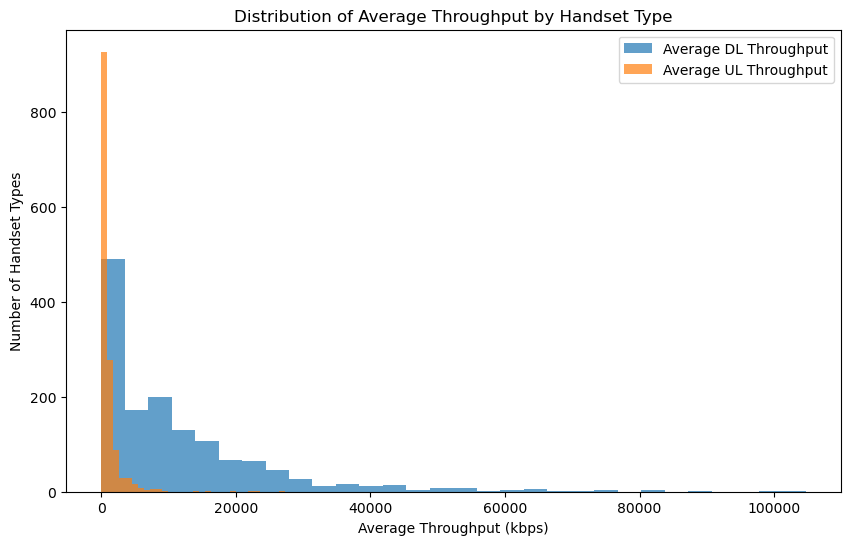

In [120]:
plt.figure(figsize=(10, 6))

plt.hist(
    throughput_by_handset["Avg_Throughput_DL"],
    bins=30,
    alpha=0.7,
    label="Average DL Throughput"
)

plt.hist(
    throughput_by_handset["Avg_Throughput_UL"],
    bins=30,
    alpha=0.7,
    label="Average UL Throughput"
)

plt.xlabel("Average Throughput (kbps)")
plt.ylabel("Number of Handset Types")
plt.title("Distribution of Average Throughput by Handset Type")
plt.legend()
plt.show()

In [121]:
tcp_retrans_by_handset = (
    experience_metrics
    .groupby("Handset_Type")
    [["Avg_TCP_DL_Retrans", "Avg_TCP_UL_Retrans"]]
    .mean()
    .sort_values("Avg_TCP_DL_Retrans", ascending=False)
)

tcp_retrans_by_handset.head(10)

,Avg_TCP_DL_Retrans,Avg_TCP_UL_Retrans
Handset_Type,,
Lg Lg-H635,1.357279e+09,NaN
Huawei Bln-Al10,3.290646e+08,1.100230e+05
Asustek Asus Zenfone Selfie Zd551Kl,3.189534e+08,2.704945e+06
Dynamic Tech Hol. D-Mobile I3 I5 I7 I8 I9,2.672434e+08,1.069236e+06
Apple iPad Pro (A1652),2.340550e+08,5.320000e+03
Huawei E5776S-32,2.280872e+08,9.790514e+05
Samsung Galaxy Tab S3 (Sm-T825),1.268012e+08,1.828750e+04
Samsung Galaxy J8 2018,1.157526e+08,5.686000e+03
Xiaomi Communica. Mi 6,7.515213e+07,2.349550e+05


In [122]:
tcp_retrans_by_handset.describe()

,Avg_TCP_DL_Retrans,Avg_TCP_UL_Retrans
count,1.191000e+03,1.073000e+03
mean,5.827274e+06,1.263249e+05
std,4.405268e+07,7.320164e+05
min,1.200000e+01,1.000000e+00
25%,6.818275e+04,7.812000e+03
50%,8.207977e+05,2.488450e+04
75%,3.023350e+06,6.494786e+04
max,1.357279e+09,1.743352e+07


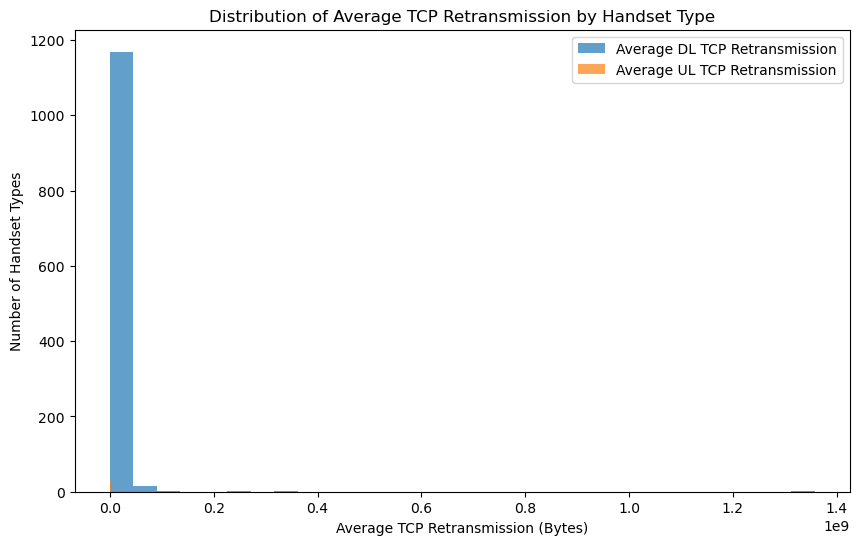

In [123]:
plt.figure(figsize=(10, 6))

plt.hist(
    tcp_retrans_by_handset["Avg_TCP_DL_Retrans"].dropna(),
    bins=30,
    alpha=0.7,
    label="Average DL TCP Retransmission"
)

plt.hist(
    tcp_retrans_by_handset["Avg_TCP_UL_Retrans"].dropna(),
    bins=30,
    alpha=0.7,
    label="Average UL TCP Retransmission"
)

plt.xlabel("Average TCP Retransmission (Bytes)")
plt.ylabel("Number of Handset Types")
plt.title("Distribution of Average TCP Retransmission by Handset Type")
plt.legend()
plt.show()

In [124]:
engagement_cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=[
        "Sessions_Score",
        "Duration_Score",
        "Traffic_Score"
    ]
)

engagement_cluster_centers

,Sessions_Score,Duration_Score,Traffic_Score
0,0.069240,0.011138,0.123913
1,0.191446,0.030397,0.255410
2,0.002460,0.005381,0.052446


In [125]:
less_engaged_center = engagement_cluster_centers.loc[2].values

engagement_metrics["Engagement_Score"] = engagement_metrics[
    [
        "Sessions_Score",
        "Duration_Score",
        "Traffic_Score"
    ]
].apply(
    lambda row: euclidean(row.values, less_engaged_center),
    axis=1
)

In [126]:
engagement_metrics["Engagement_Score"].describe()

count    106856.000000
mean          0.051034
std           0.061437
min           0.002462
25%           0.017084
50%           0.033244
75%           0.058332
max           1.641745
Name: Engagement_Score, dtype: float64

In [127]:
experience_score_features = [
    "TCP_DL_Score",
    "TCP_UL_Score",
    "RTT_DL_Score",
    "RTT_UL_Score",
    "Throughput_DL_Score",
    "Throughput_UL_Score"
]

experience_clustering_clean = experience_clustering[
    experience_score_features
].dropna()

experience_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

experience_kmeans.fit(experience_clustering_clean)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [128]:
experience_kmeans.cluster_centers_.shape

(3, 6)

In [129]:
experience_clustering.columns.tolist()

['TCP_DL_Score',
 'TCP_UL_Score',
 'RTT_DL_Score',
 'RTT_UL_Score',
 'Throughput_DL_Score',
 'Throughput_UL_Score',
 'Experience_Cluster',
 'Experience_Level']

In [130]:
worst_experience_center = experience_kmeans.cluster_centers_[0]

experience_for_distance = experience_scoring[
    experience_score_features
].copy()

experience_for_distance = experience_for_distance.fillna(
    experience_for_distance.mean()
)

experience_scoring["Experience_Score"] = np.linalg.norm(
    experience_for_distance.values - worst_experience_center,
    axis=1
)

In [131]:
experience_scoring["Experience_Score"].describe()

count    106856.000000
mean          0.860436
std           0.164852
min           0.044588
25%           0.807872
50%           0.932992
75%           0.940116
max           1.650208
Name: Experience_Score, dtype: float64

In [132]:
satisfaction = engagement_metrics[
    ["MSISDN/Number", "Engagement_Score"]
].merge(
    experience_scoring[
        ["MSISDN/Number", "Experience_Score"]
    ],
    on="MSISDN/Number",
    how="inner"
)

satisfaction["Satisfaction_Score"] = (
    satisfaction["Engagement_Score"] +
    satisfaction["Experience_Score"]
) / 2

In [133]:
satisfaction["Satisfaction_Score"].describe()

count    106856.000000
mean          0.455735
std           0.082961
min           0.046578
25%           0.435635
50%           0.477324
75%           0.489264
max           1.245903
Name: Satisfaction_Score, dtype: float64

In [134]:
top_10_satisfied = (
    satisfaction
    .sort_values("Satisfaction_Score", ascending=False)
    .head(10)
)

top_10_satisfied

,MSISDN/Number,Engagement_Score,Experience_Score,Satisfaction_Score
13180,3.362578e+10,1.641745,0.850062,1.245903
13526,3.362632e+10,1.390654,0.885634,1.138144
6437,3.361489e+10,1.435855,0.777079,1.106467
92923,3.376054e+10,1.321646,0.851964,1.086805
65118,3.366716e+10,1.024511,1.142961,1.083736
76363,3.367588e+10,1.201755,0.833095,1.017425
37052,3.365973e+10,1.220025,0.812156,1.016090
92577,3.376041e+10,1.030388,0.820159,0.925273
60114,3.366547e+10,0.621215,1.223470,0.922342
13994,3.362708e+10,0.912721,0.917863,0.915292


In [135]:

regression_data = satisfaction.merge(
    engagement_metrics[
        [
            "MSISDN/Number",
            "Sessions_Score",
            "Duration_Score",
            "Traffic_Score"
        ]
    ],
    on="MSISDN/Number",
    how="left"
).merge(
    experience_scoring[
        [
            "MSISDN/Number",
            "TCP_DL_Score",
            "TCP_UL_Score",
            "RTT_DL_Score",
            "RTT_UL_Score",
            "Throughput_DL_Score",
            "Throughput_UL_Score"
        ]
    ],
    on="MSISDN/Number",
    how="left"
)

In [136]:
regression_features = [
    "Sessions_Score",
    "Duration_Score",
    "Traffic_Score",
    "TCP_DL_Score",
    "TCP_UL_Score",
    "RTT_DL_Score",
    "RTT_UL_Score",
    "Throughput_DL_Score",
    "Throughput_UL_Score"
]

X = regression_data[regression_features].fillna(
    regression_data[regression_features].mean()
)

y = regression_data["Satisfaction_Score"]

In [137]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

LinearRegression()

In [138]:
y_pred = regression_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 0.035144720451971236
R² Score: 0.8193658145186125


In [139]:
satisfaction_clustering = satisfaction[
    [
        "Engagement_Score",
        "Experience_Score"
    ]
].copy()

satisfaction_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

satisfaction["Satisfaction_Cluster"] = (
    satisfaction_kmeans.fit_predict(satisfaction_clustering)
)

In [140]:
satisfaction_cluster_centers = pd.DataFrame(
    satisfaction_kmeans.cluster_centers_,
    columns=[
        "Engagement_Score",
        "Experience_Score"
    ]
)

satisfaction_cluster_centers

,Engagement_Score,Experience_Score
0,0.045570,0.925848
1,0.073521,0.591189


In [141]:
cluster_summary = (
    satisfaction
    .groupby("Satisfaction_Cluster")
    .agg(
        Average_Satisfaction=("Satisfaction_Score", "mean"),
        Average_Experience=("Experience_Score", "mean"),
        Average_Engagement=("Engagement_Score", "mean"),
        Number_of_Users=("MSISDN/Number", "count")
    )
    .reset_index()
)

cluster_summary

,Satisfaction_Cluster,Average_Satisfaction,Average_Experience,Average_Engagement,Number_of_Users
0,0,0.485658,0.925747,0.045569,86022
1,1,0.332186,0.590775,0.073598,20834


In [142]:
final_scores = satisfaction[
    [
        "MSISDN/Number",
        "Engagement_Score",
        "Experience_Score",
        "Satisfaction_Score"
    ]
].copy()

final_scores.head()

,MSISDN/Number,Engagement_Score,Experience_Score,Satisfaction_Score
0,3.360100e+10,0.043558,0.944072,0.493815
1,3.360100e+10,0.038706,0.942834,0.490770
2,3.360100e+10,0.011765,0.933162,0.472464
3,3.360101e+10,0.009186,0.933646,0.471416
4,3.360101e+10,0.122903,0.506161,0.314532


In [143]:

print("MySQL connector is available")

MySQL connector is available


In [144]:

connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Siddheya78$"
)

print("Connected to MySQL")

Connected to MySQL


In [145]:
cursor = connection.cursor()

cursor.execute("""
    CREATE DATABASE IF NOT EXISTS telecom_analysis
""")

print("Database created")

Database created


In [146]:
connection.database = "telecom_analysis"

print("Connected to telecom_analysis")

Connected to telecom_analysis


In [147]:
cursor.execute("""
    CREATE TABLE IF NOT EXISTS customer_scores (
        MSISDN_Number BIGINT,
        Engagement_Score DOUBLE,
        Experience_Score DOUBLE,
        Satisfaction_Score DOUBLE
    )
""")

connection.commit()

print("Table created")

Table created


In [148]:
cursor.execute("SHOW TABLES")

print(cursor.fetchall())

[('customer_scores',)]


In [149]:
final_scores = satisfaction[
    [
        "MSISDN/Number",
        "Engagement_Score",
        "Experience_Score",
        "Satisfaction_Score"
    ]
].copy()

print(final_scores.shape)
print(final_scores.head())

(106856, 4)
   MSISDN/Number  Engagement_Score  Experience_Score  Satisfaction_Score
0   3.360100e+10          0.043558          0.944072            0.493815
1   3.360100e+10          0.038706          0.942834            0.490770
2   3.360100e+10          0.011765          0.933162            0.472464
3   3.360101e+10          0.009186          0.933646            0.471416
4   3.360101e+10          0.122903          0.506161            0.314532


In [150]:
insert_query = """
INSERT INTO customer_scores
(MSISDN_Number, Engagement_Score, Experience_Score, Satisfaction_Score)
VALUES (%s, %s, %s, %s)
"""

data = list(final_scores.itertuples(index=False, name=None))

for i in range(0, len(data), 5000):
    cursor.executemany(insert_query, data[i:i+5000])
    connection.commit()
    print(f"Inserted {min(i + 5000, len(data))} / {len(data)}")

print("All rows inserted")

Inserted 5000 / 106856
Inserted 10000 / 106856
Inserted 15000 / 106856
Inserted 20000 / 106856
Inserted 25000 / 106856
Inserted 30000 / 106856
Inserted 35000 / 106856
Inserted 40000 / 106856
Inserted 45000 / 106856
Inserted 50000 / 106856
Inserted 55000 / 106856
Inserted 60000 / 106856
Inserted 65000 / 106856
Inserted 70000 / 106856
Inserted 75000 / 106856
Inserted 80000 / 106856
Inserted 85000 / 106856
Inserted 90000 / 106856
Inserted 95000 / 106856
Inserted 100000 / 106856
Inserted 105000 / 106856
Inserted 106856 / 106856
All rows inserted


In [151]:
cursor.execute("SELECT COUNT(*) FROM customer_scores")

print(cursor.fetchone())

(320568,)


In [152]:
cursor.execute("""
    SELECT *
    FROM customer_scores
    LIMIT 10
""")

for row in cursor.fetchall():
    print(row)

(33601001722, 0.04355818539510647, 0.9440717467641009, 0.4938149660796037)
(33601001754, 0.03870648712304523, 0.9428337539172182, 0.49077012052013175)
(33601002511, 0.011764811935854307, 0.933162339471773, 0.47246357570381364)
(33601007832, 0.00918606870048761, 0.9336462669746703, 0.471416167837579)
(33601008617, 0.12290328956435753, 0.5061612134225348, 0.3145322514934462)
(33601010682, 0.05851786490280158, 0.9144172021900604, 0.48646753354643096)
(33601011634, 0.05920091638780532, 0.8000665637569814, 0.42963374007239336)
(33601011959, 0.01866808437487576, 0.9208522585659947, 0.46976017147043525)
(33601014694, 0.0822607430743225, 0.9329485043328861, 0.5076046237036043)
(33601020306, 0.02702280130244116, 0.9436742127139969, 0.485348507008219)


In [153]:
%pip install mlflow

Note: you may need to restart the kernel to use updated packages.


In [154]:
print("MLflow:", mlflow.__version__)
print("scikit-learn:", sklearn.__version__)

MLflow: 3.16.1
scikit-learn: 1.6.1


In [155]:
mlflow.set_experiment("Telecom Customer Satisfaction")

print("MLflow experiment ready")

MLflow experiment ready


In [156]:
with mlflow.start_run(run_name="Satisfaction Regression Model"):

    mlflow.log_param("model_type", "Linear Regression")
    mlflow.log_param("test_size", 0.2)
    mlflow.log_param("random_state", 42)

    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("R2", r2)

    mlflow.sklearn.log_model(
        regression_model,
        name="satisfaction_regression_model"
    )

    print("Model logged successfully")

2026/09/28 12:37:03 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet

2026/09/28 12:37:03 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably

Model logged successfully


In [157]:
runs = mlflow.search_runs()

runs[
    [
        "run_id",
        "status",
        "metrics.RMSE",
        "metrics.R2",
        "params.model_type"
    ]
]

,run_id,status,metrics.RMSE,metrics.R2,params.model_type
0,fcf10b78b0ad4fcc98277853c9812952,FINISHED,0.035145,0.819366,Linear Regression
1,4abf9f8a3cac4c0c87761abe7803dcf5,FINISHED,0.035145,0.819366,Linear Regression
2,fd6e2ba280b54db183500d339ea2f2d1,FINISHED,0.035145,0.819366,Linear Regression
3,c1cb16e2ef6f4064a36162aeff38223e,FINISHED,0.035145,0.819366,Linear Regression


In [158]:

joblib.dump(regression_model, "satisfaction_regression_model.pkl")

print("Model saved successfully")

Model saved successfully


In [159]:

print(os.path.exists("satisfaction_regression_model.pkl"))

True


In [160]:
print(os.path.abspath("satisfaction_regression_model.pkl"))

C:\Users\Sidd\satisfaction_regression_model.pkl


In [161]:
print("User aggregation:", user_aggregation.shape)
print("Experience metrics:", experience_metrics.shape)
print("Satisfaction:", satisfaction.shape)
print("Final scores:", final_scores.shape)
print("Regression R²:", r2)
print("Regression RMSE:", rmse)

User aggregation: (106856, 6)
Experience metrics: (106856, 8)
Satisfaction: (106856, 5)
Final scores: (106856, 4)
Regression R²: 0.8193658145186125
Regression RMSE: 0.035144720451971236


In [166]:
from src.features import build_feature_store

feature_store = build_feature_store(df1)

print(feature_store.shape)
feature_store.head()

(106856, 12)


,MSISDN/Number,Number_of_Sessions,Total_Duration_ms,Total_DL_Bytes,Total_UL_Bytes,Total_Traffic_Bytes,Avg_TCP_DL_Retrans,Avg_TCP_UL_Retrans,Avg_RTT_DL,Avg_RTT_UL,Avg_Throughput_DL,Avg_Throughput_UL
0,3.360100e+10,1,116720.0,8.426375e+08,36053108.0,8.786906e+08,NaN,NaN,46.0,0.0,37.0,39.0
1,3.360100e+10,1,181230.0,1.207552e+08,36104459.0,1.568596e+08,NaN,NaN,30.0,1.0,48.0,51.0
2,3.360100e+10,1,134969.0,5.566597e+08,39306820.0,5.959665e+08,NaN,NaN,NaN,NaN,48.0,49.0
3,3.360101e+10,1,49878.0,4.019932e+08,20327526.0,4.223207e+08,1066.0,NaN,69.0,15.0,204.0,44.0
4,3.360101e+10,2,37104.0,1.363130e+09,94280527.0,1.457411e+09,9349630.0,21202.0,57.0,2.5,20197.5,8224.5


In [167]:
feature_store.to_csv(
    r"C:\Users\Sidd\telecom-user-analytics\feature_store\customer_features.csv",
    index=False
)

print("Feature store saved successfully")

Feature store saved successfully
